In [2]:
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------
# 1. Load frozen feature store
# ---------------------------------------------------------

FEATURE_PATH = Path("../data/processed/features.parquet")
CONFIG_PATH = Path("../configs/split_config.json")

features = pd.read_parquet(FEATURE_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    split_config = json.load(f)

# Ensure datetime
features["snapshot_date"] = pd.to_datetime(features["snapshot_date"])

print("Feature store loaded")
print(f"Shape: {features.shape}")
print(f"Customers: {features['customer_id'].nunique():,}")
print(f"Snapshots: {features['snapshot_date'].nunique()}")
print(f"Positive labels: {features['churn_90d'].sum():,}")

Feature store loaded
Shape: (424607, 101)
Customers: 11,716
Snapshots: 93
Positive labels: 23,029


In [3]:
# ---------------------------------------------------------
# 2. Recreate frozen temporal splits
# ---------------------------------------------------------

train_start = pd.Timestamp(split_config["train"]["start"])
train_end = pd.Timestamp(split_config["train"]["end"])

val_start = pd.Timestamp(split_config["validation"]["start"])
val_end = pd.Timestamp(split_config["validation"]["end"])

test_start = pd.Timestamp(split_config["test"]["start"])
test_end = pd.Timestamp(split_config["test"]["end"])


train = features[
    (features["snapshot_date"] >= train_start) &
    (features["snapshot_date"] <= train_end)
].copy()

validation = features[
    (features["snapshot_date"] >= val_start) &
    (features["snapshot_date"] <= val_end)
].copy()

test = features[
    (features["snapshot_date"] >= test_start) &
    (features["snapshot_date"] <= test_end)
].copy()


print("TRAIN")
print(train.shape)

print("\nVALIDATION")
print(validation.shape)

print("\nTEST")
print(test.shape)

TRAIN
(112685, 101)

VALIDATION
(62347, 101)

TEST
(90358, 101)


In [4]:
# ---------------------------------------------------------
# 3. Verify frozen split
# ---------------------------------------------------------

assert len(train) == 112_685
assert len(validation) == 62_347
assert len(test) == 90_358

assert train["churn_90d"].sum() == 6_080
assert validation["churn_90d"].sum() == 3_435
assert test["churn_90d"].sum() == 4_963

assert train["snapshot_date"].max() < validation["snapshot_date"].min()
assert validation["snapshot_date"].max() < test["snapshot_date"].min()

print("✓ Split reproduced exactly")
print("✓ Row counts match")
print("✓ Positive labels match")
print("✓ Temporal ordering valid")

✓ Split reproduced exactly
✓ Row counts match
✓ Positive labels match
✓ Temporal ordering valid


In [5]:
# ---------------------------------------------------------
# 1. Inspect feature columns
# ---------------------------------------------------------

for i, col in enumerate(features.columns, 1):
    print(f"{i:3}. {col}")

  1. customer_id
  2. snapshot_date
  3. churn_90d
  4. industry
  5. region
  6. segment
  7. company_size
  8. acquisition_channel
  9. tenure_days
 10. tenure_years
 11. health_score
 12. baseline_health
 13. health_trend
 14. volatility
 15. behaviour
 16. health_score_change_4w
 17. health_score_change_8w
 18. health_score_change_12w
 19. health_score_pct_change_4w
 20. health_score_pct_change_8w
 21. health_score_pct_change_12w
 22. active_users
 23. sessions
 24. active_days
 25. usage_minutes
 26. features_used
 27. p001_sessions
 28. p002_sessions
 29. p003_sessions
 30. p004_sessions
 31. p005_sessions
 32. active_users_change_4w
 33. active_users_change_8w
 34. active_users_change_12w
 35. sessions_change_4w
 36. sessions_change_8w
 37. sessions_change_12w
 38. usage_minutes_change_4w
 39. usage_minutes_change_8w
 40. usage_minutes_change_12w
 41. active_days_change_4w
 42. active_days_change_8w
 43. active_days_change_12w
 44. features_used_change_4w
 45. features_used_chan

In [6]:
# ---------------------------------------------------------
# 2. Identify column types
# ---------------------------------------------------------

target = "churn_90d"

id_columns = [
    "customer_id",
    "contract_id",
    "snapshot_date",
]

constant_columns = [
    "contract_active",
]

# Check which of these actually exist
id_columns = [c for c in id_columns if c in train.columns]
constant_columns = [c for c in constant_columns if c in train.columns]

print("ID / identifier columns:")
print(id_columns)

print("\nConstant columns:")
print(constant_columns)

print("\nCategorical columns:")
categorical_columns = train.drop(
    columns=[target] + id_columns,
    errors="ignore"
).select_dtypes(include=["object", "category"]).columns.tolist()

print(categorical_columns)

print("\nNumeric columns:")
numeric_columns = train.drop(
    columns=[target] + id_columns,
    errors="ignore"
).select_dtypes(include=["number", "bool"]).columns.tolist()

print(f"Count: {len(numeric_columns)}")
print(numeric_columns)

ID / identifier columns:
['customer_id', 'contract_id', 'snapshot_date']

Constant columns:
['contract_active']

Categorical columns:
['industry', 'region', 'segment', 'acquisition_channel', 'behaviour', 'contract_type']

Numeric columns:
Count: 91
['company_size', 'tenure_days', 'tenure_years', 'health_score', 'baseline_health', 'health_trend', 'volatility', 'health_score_change_4w', 'health_score_change_8w', 'health_score_change_12w', 'health_score_pct_change_4w', 'health_score_pct_change_8w', 'health_score_pct_change_12w', 'active_users', 'sessions', 'active_days', 'usage_minutes', 'features_used', 'p001_sessions', 'p002_sessions', 'p003_sessions', 'p004_sessions', 'p005_sessions', 'active_users_change_4w', 'active_users_change_8w', 'active_users_change_12w', 'sessions_change_4w', 'sessions_change_8w', 'sessions_change_12w', 'usage_minutes_change_4w', 'usage_minutes_change_8w', 'usage_minutes_change_12w', 'active_days_change_4w', 'active_days_change_8w', 'active_days_change_12w', 'f

C:\Users\yadav\AppData\Local\Temp\ipykernel_23696\4294349653.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ).select_dtypes(include=["object", "category"]).columns.tolist()


In [7]:
# ---------------------------------------------------------
# 3. Columns excluded from modeling
# ---------------------------------------------------------

DROP_FOR_MODEL = [
    "customer_id",
    "contract_id",
    "snapshot_date",
    "contract_active",
    "contract_age_days",
]

DROP_FOR_MODEL = [
    c for c in DROP_FOR_MODEL
    if c in train.columns
]

print("Excluded from model:")
for col in DROP_FOR_MODEL:
    print(f"  - {col}")

Excluded from model:
  - customer_id
  - contract_id
  - snapshot_date
  - contract_active
  - contract_age_days


In [8]:
# ---------------------------------------------------------
# 4. Create X / y
# ---------------------------------------------------------

TARGET = "churn_90d"

X_train = train.drop(columns=[TARGET] + DROP_FOR_MODEL)
y_train = train[TARGET]

X_val = validation.drop(columns=[TARGET] + DROP_FOR_MODEL)
y_val = validation[TARGET]

X_test = test.drop(columns=[TARGET] + DROP_FOR_MODEL)
y_test = test[TARGET]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (112685, 95)
X_val:   (62347, 95)
X_test:  (90358, 95)

y_train: (112685,)
y_val:   (62347,)
y_test:  (90358,)


In [9]:
print("\nRemaining feature types:")
print(X_train.dtypes.value_counts())

print("\nCategorical features:")
print(
    X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

print("\nNumeric feature count:")
print(
    len(
        X_train.select_dtypes(
            include=["number", "bool"]
        ).columns
    )
)


Remaining feature types:
float64    65
int64      23
str         6
bool        1
Name: count, dtype: int64

Categorical features:
['industry', 'region', 'segment', 'acquisition_channel', 'behaviour', 'contract_type']

Numeric feature count:
89


C:\Users\yadav\AppData\Local\Temp\ipykernel_23696\1616536430.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(


In [13]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- --------

In [14]:
# =========================================================
# LOGISTIC REGRESSION — PREPROCESSING
# =========================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


# ---------------------------------------------------------
# 1. Identify feature types
# ---------------------------------------------------------

categorical_features = X_train.select_dtypes(
    include=["str", "object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nCategorical:")
print(categorical_features)

Numeric features:     89
Categorical features: 6

Categorical:
['industry', 'region', 'segment', 'acquisition_channel', 'behaviour', 'contract_type']


In [15]:
# ---------------------------------------------------------
# 2. Numerical preprocessing
# ---------------------------------------------------------

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# ---------------------------------------------------------
# 3. Categorical preprocessing
# ---------------------------------------------------------

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


# ---------------------------------------------------------
# 4. Combined preprocessing
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [16]:
# =========================================================
# LOGISTIC REGRESSION — BASELINE
# =========================================================

from sklearn.linear_model import LogisticRegression


logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
            random_state=42
        )
    )
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [17]:
# ---------------------------------------------------------
# Train Logistic Regression
# ---------------------------------------------------------

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training Logistic Regression...
Training complete.


In [18]:
# ---------------------------------------------------------
# Generate probabilities
# ---------------------------------------------------------

train_proba = logistic_model.predict_proba(X_train)[:, 1]
val_proba = logistic_model.predict_proba(X_val)[:, 1]
test_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated.")

print("\nTrain probability range:")
print(train_proba.min(), "→", train_proba.max())

print("\nValidation probability range:")
print(val_proba.min(), "→", val_proba.max())

print("\nTest probability range:")
print(test_proba.min(), "→", test_proba.max())

Probability predictions generated.

Train probability range:
0.00024561032196618494 → 0.9821854696548028

Validation probability range:
1.3684520308037365e-13 → 1.0

Test probability range:
6.778726262367487e-16 → 1.0


In [19]:
# =========================================================
# LOGISTIC REGRESSION — BASELINE EVALUATION
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

# ---------------------------------------------------------
# 1. Predictions at the default 0.5 threshold
# ---------------------------------------------------------

train_pred = (train_proba >= 0.5).astype(int)
val_pred = (val_proba >= 0.5).astype(int)
test_pred = (test_proba >= 0.5).astype(int)


# ---------------------------------------------------------
# 2. Evaluation function
# ---------------------------------------------------------

def evaluate_model(name, y_true, y_proba, y_pred):
    
    print("=" * 70)
    print(name)
    print("=" * 70)
    
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    brier = brier_score_loss(y_true, y_proba)
    
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Brier:     {brier:.4f}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            digits=4,
            zero_division=0
        )
    )
    
    return {
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Brier": brier
    }


# ---------------------------------------------------------
# 3. Evaluate
# ---------------------------------------------------------

train_results = evaluate_model(
    "TRAIN",
    y_train,
    train_proba,
    train_pred
)

val_results = evaluate_model(
    "VALIDATION",
    y_val,
    val_proba,
    val_pred
)

test_results = evaluate_model(
    "TEST",
    y_test,
    test_proba,
    test_pred
)

TRAIN
ROC-AUC:   0.8099
PR-AUC:    0.2221
Accuracy:  0.7440
Precision: 0.1389
Recall:    0.7201
F1:        0.2329
Brier:     0.1768

Confusion Matrix:
[[79465 27140]
 [ 1702  4378]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9790    0.7454    0.8464    106605
           1     0.1389    0.7201    0.2329      6080

    accuracy                         0.7440    112685
   macro avg     0.5590    0.7327    0.5396    112685
weighted avg     0.9337    0.7440    0.8133    112685

VALIDATION
ROC-AUC:   0.7934
PR-AUC:    0.2436
Accuracy:  0.7618
Precision: 0.1489
Recall:    0.7051
F1:        0.2459
Brier:     0.1754

Confusion Matrix:
[[45072 13840]
 [ 1013  2422]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9780    0.7651    0.8585     58912
           1     0.1489    0.7051    0.2459      3435

    accuracy                         0.7618     62347
   macro avg     0.5635    0.7351    0

In [20]:
# =========================================================
# BASELINE RESULTS SUMMARY
# =========================================================

results_df = pd.DataFrame(
    [train_results, val_results, test_results],
    index=["Train", "Validation", "Test"]
)

display(results_df.round(4))

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Brier
Train,0.8099,0.2221,0.7440,0.1389,0.7201,0.2329,0.1768
Validation,0.7934,0.2436,0.7618,0.1489,0.7051,0.2459,0.1754
Test,0.8094,0.2366,0.7688,0.1531,0.7080,0.2517,0.1740


In [21]:
# =========================================================
# PREDICTION DISTRIBUTION
# =========================================================

for name, proba in [
    ("Train", train_proba),
    ("Validation", val_proba),
    ("Test", test_proba)
]:
    print(f"\n{name}")
    print("-" * 40)
    print(
        pd.Series(proba).describe(
            percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
        )
    )


Train
----------------------------------------
count    112685.000000
mean          0.371511
std           0.233105
min           0.000246
1%            0.043199
5%            0.083051
10%           0.112382
25%           0.183876
50%           0.311100
75%           0.534214
90%           0.740790
95%           0.828190
99%           0.917981
max           0.982185
dtype: float64

Validation
----------------------------------------
count    6.234700e+04
mean     3.667121e-01
std      2.381241e-01
min      1.368452e-13
1%       4.141782e-02
5%       8.136930e-02
10%      1.099405e-01
25%      1.794958e-01
50%      2.995031e-01
75%      5.136315e-01
90%      7.592284e-01
95%      8.473196e-01
99%      9.310104e-01
max      1.000000e+00
dtype: float64

Test
----------------------------------------
count    9.035800e+04
mean     3.655136e-01
std      2.397980e-01
min      6.778726e-16
1%       4.339022e-02
5%       8.313014e-02
10%      1.110615e-01
25%      1.770683e-01
50%      2.97692

In [22]:
# =========================================================
# THRESHOLD ANALYSIS — VALIDATION SET
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    val_pred = (val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    flagged_count = val_pred.sum()
    flagged_rate = val_pred.mean()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "flagged_customers": flagged_count,
        "flagged_rate": flagged_rate
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,threshold,precision,recall,f1,flagged_customers,flagged_rate
0,0.05,0.0556,0.9936,0.1054,61355,0.9841
1,0.10,0.0590,0.9828,0.1113,57257,0.9184
2,0.15,0.0652,0.9648,0.1221,50850,0.8156
3,0.20,0.0725,0.9263,0.1346,43860,0.7035
4,0.25,0.0814,0.8806,0.1490,37157,0.5960
5,0.30,0.0927,0.8393,0.1669,31112,0.4990
6,0.35,0.1049,0.7991,0.1855,26162,0.4196
7,0.40,0.1197,0.7706,0.2072,22116,0.3547
8,0.45,0.1342,0.7377,0.2271,18879,0.3028
9,0.50,0.1489,0.7051,0.2459,16262,0.2608


In [23]:
# =========================================================
# BEST F1 THRESHOLD
# =========================================================

best_f1 = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best F1 threshold")
print("-" * 40)
print(best_f1)

Best F1 threshold
----------------------------------------
threshold               0.750000
precision               0.241337
recall                  0.460262
f1                      0.316643
flagged_customers    6551.000000
flagged_rate            0.105073
Name: 14, dtype: float64


In [24]:
# =========================================================
# BUSINESS-ORIENTED THRESHOLD VIEW
# =========================================================

business_thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

business_results = []

for threshold in business_thresholds:

    pred = (val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    business_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "customers_flagged": pred.sum(),
        "flagged_percentage": pred.mean() * 100
    })

business_threshold_df = pd.DataFrame(business_results)

display(
    business_threshold_df.round(4)
)

,threshold,precision,recall,f1,customers_flagged,flagged_percentage
0,0.10,0.0590,0.9828,0.1113,57257,91.8360
1,0.15,0.0652,0.9648,0.1221,50850,81.5597
2,0.20,0.0725,0.9263,0.1346,43860,70.3482
3,0.25,0.0814,0.8806,0.1490,37157,59.5971
4,0.30,0.0927,0.8393,0.1669,31112,49.9014
5,0.35,0.1049,0.7991,0.1855,26162,41.9619
6,0.40,0.1197,0.7706,0.2072,22116,35.4724
7,0.45,0.1342,0.7377,0.2271,18879,30.2805
8,0.50,0.1489,0.7051,0.2459,16262,26.0831
9,0.55,0.1658,0.6783,0.2665,14050,22.5352


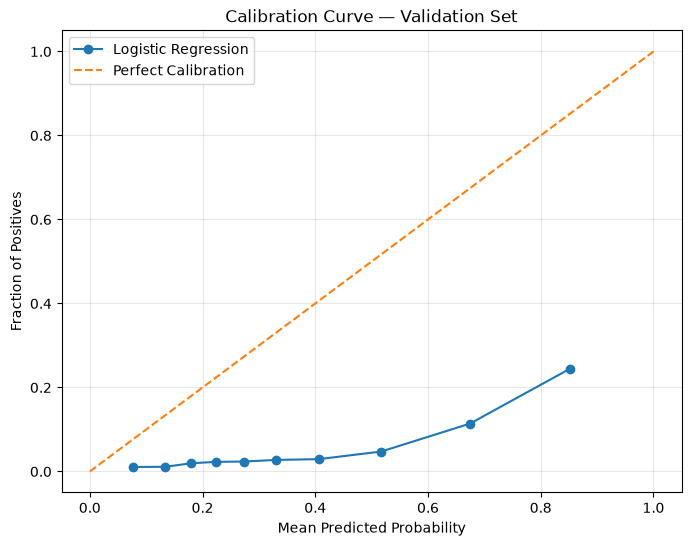

In [25]:
# =========================================================
# CALIBRATION CURVE — VALIDATION
# =========================================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val,
    val_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Validation Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
# =========================================================
# CALIBRATION TABLE
# =========================================================

calibration_data = pd.DataFrame({
    "actual": y_val.values,
    "predicted_probability": val_proba
})

calibration_data["risk_bin"] = pd.qcut(
    calibration_data["predicted_probability"],
    q=10,
    duplicates="drop"
)

calibration_table = (
    calibration_data
    .groupby("risk_bin", observed=True)
    .agg(
        customers=("actual", "size"),
        mean_predicted_risk=("predicted_probability", "mean"),
        actual_churn_rate=("actual", "mean")
    )
    .reset_index()
)

calibration_table["calibration_gap"] = (
    calibration_table["mean_predicted_risk"]
    - calibration_table["actual_churn_rate"]
)

display(
    calibration_table.round(4)
)

,risk_bin,customers,mean_predicted_risk,actual_churn_rate,calibration_gap
0,"(-0.000999999999863, 0.11]",6235,0.0764,0.0107,0.0657
1,"(0.11, 0.157]",6235,0.1340,0.0112,0.1227
2,"(0.157, 0.202]",6234,0.1796,0.0196,0.1600
3,"(0.202, 0.248]",6235,0.2244,0.0229,0.2015
4,"(0.248, 0.3]",6235,0.2733,0.0237,0.2496
5,"(0.3, 0.364]",6234,0.3307,0.0276,0.3031
6,"(0.364, 0.453]",6235,0.4058,0.0294,0.3764
7,"(0.453, 0.59]",6234,0.5170,0.0475,0.4695
8,"(0.59, 0.759]",6235,0.6746,0.1140,0.5605
9,"(0.759, 1.0]",6235,0.8514,0.2443,0.6071


In [27]:
    # =========================================================
# BRIER SCORE
# =========================================================

from sklearn.metrics import brier_score_loss

baseline_brier = brier_score_loss(
    y_val,
    val_proba
)

print(f"Validation Brier Score: {baseline_brier:.4f}")

Validation Brier Score: 0.1754


In [28]:
# =========================================================
# LOGISTIC REGRESSION — CALIBRATED VERSION
# =========================================================

from sklearn.calibration import CalibratedClassifierCV

calibrated_logistic = CalibratedClassifierCV(
    estimator=logistic_model,
    method="sigmoid",
    cv=5,
    ensemble=True
)

print("Calibrated Logistic Regression created.")

Calibrated Logistic Regression created.


In [29]:
# =========================================================
# TRAIN CALIBRATED MODEL
# =========================================================

print("Training calibrated Logistic Regression...")

calibrated_logistic.fit(
    X_train,
    y_train
)

print("Calibration training complete.")

Training calibrated Logistic Regression...
Calibration training complete.


In [30]:
# =========================================================
# CALIBRATED PROBABILITIES
# =========================================================

cal_train_proba = calibrated_logistic.predict_proba(
    X_train
)[:, 1]

cal_val_proba = calibrated_logistic.predict_proba(
    X_val
)[:, 1]

cal_test_proba = calibrated_logistic.predict_proba(
    X_test
)[:, 1]

print("Calibrated probabilities generated.")

print("\nMean predicted probability:")
print(f"Train:      {cal_train_proba.mean():.4f}")
print(f"Validation: {cal_val_proba.mean():.4f}")
print(f"Test:       {cal_test_proba.mean():.4f}")

print("\nActual churn rates:")
print(f"Train:      {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test:       {y_test.mean():.4f}")

Calibrated probabilities generated.

Mean predicted probability:
Train:      0.0539
Validation: 0.0555
Test:       0.0566

Actual churn rates:
Train:      0.0540
Validation: 0.0551
Test:       0.0549


In [31]:
# =========================================================
# BEFORE vs AFTER CALIBRATION
# =========================================================

from sklearn.metrics import brier_score_loss

uncalibrated_brier = brier_score_loss(
    y_val,
    val_proba
)

calibrated_brier = brier_score_loss(
    y_val,
    cal_val_proba
)

print("Validation Brier Score")
print("-" * 40)
print(f"Uncalibrated: {uncalibrated_brier:.4f}")
print(f"Calibrated:   {calibrated_brier:.4f}")

Validation Brier Score
----------------------------------------
Uncalibrated: 0.1754
Calibrated:   0.0464


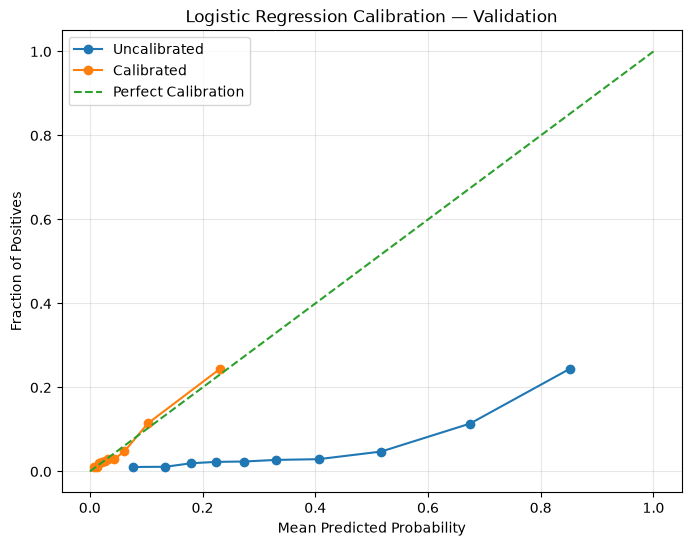

In [32]:
# =========================================================
# CALIBRATION CURVE — BEFORE vs AFTER
# =========================================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Original model
original_fraction, original_mean = calibration_curve(
    y_val,
    val_proba,
    n_bins=10,
    strategy="quantile"
)

# Calibrated model
calibrated_fraction, calibrated_mean = calibration_curve(
    y_val,
    cal_val_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    original_mean,
    original_fraction,
    marker="o",
    label="Uncalibrated"
)

plt.plot(
    calibrated_mean,
    calibrated_fraction,
    marker="o",
    label="Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Logistic Regression Calibration — Validation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
# =========================================================
# CALIBRATED RISK BINS
# =========================================================

calibration_data = pd.DataFrame({
    "actual": y_val.values,
    "predicted_probability": cal_val_proba
})

calibration_data["risk_bin"] = pd.qcut(
    calibration_data["predicted_probability"],
    q=10,
    duplicates="drop"
)

calibration_table_calibrated = (
    calibration_data
    .groupby("risk_bin", observed=True)
    .agg(
        customers=("actual", "size"),
        mean_predicted_risk=("predicted_probability", "mean"),
        actual_churn_rate=("actual", "mean")
    )
    .reset_index()
)

calibration_table_calibrated["calibration_gap"] = (
    calibration_table_calibrated["mean_predicted_risk"]
    - calibration_table_calibrated["actual_churn_rate"]
)

display(
    calibration_table_calibrated.round(4)
)

,risk_bin,customers,mean_predicted_risk,actual_churn_rate,calibration_gap
0,"(-0.0009344, 0.0105]",6235,0.0076,0.0104,-0.0028
1,"(0.0105, 0.0148]",6235,0.0127,0.0117,0.0010
2,"(0.0148, 0.019]",6234,0.0169,0.0191,-0.0022
3,"(0.019, 0.0236]",6235,0.0212,0.0217,-0.0004
4,"(0.0236, 0.0291]",6235,0.0263,0.0241,0.0022
5,"(0.0291, 0.0369]",6234,0.0328,0.0289,0.0039
6,"(0.0369, 0.0496]",6235,0.0426,0.0289,0.0138
7,"(0.0496, 0.0765]",6234,0.0612,0.0478,0.0134
8,"(0.0765, 0.137]",6235,0.1030,0.1145,-0.0115
9,"(0.137, 0.802]",6235,0.2306,0.2439,-0.0134


In [34]:
# =========================================================
# THRESHOLD ANALYSIS — CALIBRATED MODEL
# =========================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.01, 0.51, 0.01)

calibrated_threshold_results = []

for threshold in thresholds:

    val_pred = (
        cal_val_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    flagged_count = val_pred.sum()
    flagged_rate = val_pred.mean()

    calibrated_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "customers_flagged": flagged_count,
        "flagged_percentage": flagged_rate * 100
    })

calibrated_threshold_df = pd.DataFrame(
    calibrated_threshold_results
)

display(
    calibrated_threshold_df.round(4)
)

,threshold,precision,recall,f1,customers_flagged,flagged_percentage
0,0.01,0.0595,0.9840,0.1122,56832,91.1543
1,0.02,0.0745,0.9138,0.1377,42149,67.6039
2,0.03,0.0946,0.8358,0.1700,30339,48.6615
3,0.04,0.1157,0.7755,0.2014,23019,36.9208
4,0.05,0.1361,0.7365,0.2298,18583,29.8058
5,0.06,0.1538,0.7007,0.2523,15646,25.0950
6,0.07,0.1694,0.6713,0.2706,13611,21.8310
7,0.08,0.1842,0.6402,0.2861,11937,19.1461
8,0.09,0.1957,0.6079,0.2961,10667,17.1091
9,0.10,0.2049,0.5683,0.3012,9526,15.2790


In [35]:
# =========================================================
# BEST F1 THRESHOLD — CALIBRATED MODEL
# =========================================================

best_calibrated_f1 = calibrated_threshold_df.loc[
    calibrated_threshold_df["f1"].idxmax()
]

print("Best F1 threshold after calibration")
print("-" * 50)
print(best_calibrated_f1)

Best F1 threshold after calibration
--------------------------------------------------
threshold                0.130000
precision                0.239414
recall                   0.470742
f1                       0.317401
customers_flagged     6754.000000
flagged_percentage      10.832919
Name: 12, dtype: float64


In [36]:
# =========================================================
# BUSINESS-INTERPRETABLE RISK THRESHOLDS
# =========================================================

risk_thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40
]

risk_threshold_results = []

for threshold in risk_thresholds:

    pred = (
        cal_val_proba >= threshold
    ).astype(int)

    risk_threshold_results.append({
        "risk_threshold": threshold,
        "precision": precision_score(
            y_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            pred,
            zero_division=0
        ),
        "customers_flagged": pred.sum(),
        "flagged_percentage": pred.mean() * 100
    })

risk_threshold_df = pd.DataFrame(
    risk_threshold_results
)

display(
    risk_threshold_df.round(4)
)

,risk_threshold,precision,recall,f1,customers_flagged,flagged_percentage
0,0.05,0.1361,0.7365,0.2298,18583,29.8058
1,0.10,0.2049,0.5683,0.3012,9526,15.2790
2,0.15,0.2539,0.4052,0.3122,5482,8.7927
3,0.20,0.3121,0.2920,0.3017,3214,5.1550
4,0.25,0.3706,0.2084,0.2668,1932,3.0988
5,0.30,0.4237,0.1397,0.2102,1133,1.8172
6,0.35,0.4754,0.0844,0.1434,610,0.9784
7,0.40,0.4957,0.0504,0.0914,349,0.5598


In [37]:
# =========================================================
# CALIBRATED MODEL PERFORMANCE
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

calibrated_val_roc_auc = roc_auc_score(
    y_val,
    cal_val_proba
)

calibrated_val_pr_auc = average_precision_score(
    y_val,
    cal_val_proba
)

print("CALIBRATED LOGISTIC REGRESSION — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {calibrated_val_roc_auc:.4f}")
print(f"PR-AUC:  {calibrated_val_pr_auc:.4f}")

print("\nORIGINAL LOGISTIC REGRESSION")
print("-" * 55)
print(f"ROC-AUC: {roc_auc_score(y_val, val_proba):.4f}")
print(f"PR-AUC:  {average_precision_score(y_val, val_proba):.4f}")

CALIBRATED LOGISTIC REGRESSION — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.7943
PR-AUC:  0.2460

ORIGINAL LOGISTIC REGRESSION
-------------------------------------------------------
ROC-AUC: 0.7934
PR-AUC:  0.2436


In [38]:
# =========================================================
# VALIDATION PERFORMANCE AT 13%
# =========================================================

FINAL_BASELINE_THRESHOLD = 0.13

val_pred_13 = (
    cal_val_proba >= FINAL_BASELINE_THRESHOLD
).astype(int)

print("VALIDATION @ 13% THRESHOLD")
print("-" * 55)

print(
    f"Precision: "
    f"{precision_score(y_val, val_pred_13, zero_division=0):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_val, val_pred_13, zero_division=0):.4f}"
)

print(
    f"F1:        "
    f"{f1_score(y_val, val_pred_13, zero_division=0):.4f}"
)

print(
    f"Flagged:   "
    f"{val_pred_13.sum():,}"
)

print(
    f"Flagged %: "
    f"{val_pred_13.mean() * 100:.2f}%"
)

VALIDATION @ 13% THRESHOLD
-------------------------------------------------------
Precision: 0.2394
Recall:    0.4707
F1:        0.3174
Flagged:   6,754
Flagged %: 10.83%


In [39]:
# =========================================================
# SAVE LOGISTIC REGRESSION BASELINE RESULTS
# =========================================================

logistic_baseline = {
    "model": "Logistic Regression",
    "calibration": "Sigmoid",
    "validation_roc_auc": calibrated_val_roc_auc,
    "validation_pr_auc": calibrated_val_pr_auc,
    "validation_brier": calibrated_brier,
    "threshold_candidate": 0.13,
    "precision_at_threshold": 0.2394,
    "recall_at_threshold": 0.4707,
    "f1_at_threshold": 0.3174,
    "flagged_percentage": 10.83
}

logistic_baseline

{'model': 'Logistic Regression',
 'calibration': 'Sigmoid',
 'validation_roc_auc': 0.7943472839266047,
 'validation_pr_auc': 0.24602732584471687,
 'validation_brier': 0.046374481061767205,
 'threshold_candidate': 0.13,
 'precision_at_threshold': 0.2394,
 'recall_at_threshold': 0.4707,
 'f1_at_threshold': 0.3174,
 'flagged_percentage': 10.83}

In [40]:
# =========================================================
# RANDOM FOREST — PREPROCESSING
# =========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Identify feature types
rf_categorical_features = X_train.select_dtypes(
    include=["str", "object", "category"]
).columns.tolist()

rf_numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print(f"Numeric features:     {len(rf_numeric_features)}")
print(f"Categorical features: {len(rf_categorical_features)}")
print("\nCategorical features:")
print(rf_categorical_features)

Numeric features:     89
Categorical features: 6

Categorical features:
['industry', 'region', 'segment', 'acquisition_channel', 'behaviour', 'contract_type']


In [41]:
# ---------------------------------------------------------
# Numerical preprocessing
# ---------------------------------------------------------

rf_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])


# ---------------------------------------------------------
# Categorical preprocessing
# ---------------------------------------------------------

rf_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


# ---------------------------------------------------------
# Combined preprocessing
# ---------------------------------------------------------

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            rf_numeric_pipeline,
            rf_numeric_features
        ),
        (
            "categorical",
            rf_categorical_pipeline,
            rf_categorical_features
        )
    ]
)

print("Random Forest preprocessing pipeline created.")

Random Forest preprocessing pipeline created.


In [42]:
# =========================================================
# RANDOM FOREST — BASELINE
# =========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    (
        "preprocessor",
        rf_preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )
    )
])

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [43]:
# =========================================================
# TRAIN RANDOM FOREST
# =========================================================

print("Training Random Forest...")
print("This may take a while.")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Training Random Forest...
This may take a while.
Random Forest training complete.


In [44]:
# =========================================================
# RANDOM FOREST — PREDICTIONS
# =========================================================

rf_train_proba = rf_model.predict_proba(
    X_train
)[:, 1]

rf_val_proba = rf_model.predict_proba(
    X_val
)[:, 1]

rf_test_proba = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest probabilities generated.")

print("\nProbability ranges:")

print(
    f"Train:      "
    f"{rf_train_proba.min():.6f} → "
    f"{rf_train_proba.max():.6f}"
)

print(
    f"Validation: "
    f"{rf_val_proba.min():.6f} → "
    f"{rf_val_proba.max():.6f}"
)

print(
    f"Test:       "
    f"{rf_test_proba.min():.6f} → "
    f"{rf_test_proba.max():.6f}"
)

Random Forest probabilities generated.

Probability ranges:
Train:      0.000000 → 0.981763
Validation: 0.000000 → 0.899537
Test:       0.000000 → 0.889903


In [45]:
# =========================================================
# RANDOM FOREST — RAW PERFORMANCE
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

rf_val_roc_auc = roc_auc_score(
    y_val,
    rf_val_proba
)

rf_val_pr_auc = average_precision_score(
    y_val,
    rf_val_proba
)

rf_val_brier = brier_score_loss(
    y_val,
    rf_val_proba
)

print("RANDOM FOREST — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {rf_val_roc_auc:.4f}")
print(f"PR-AUC:  {rf_val_pr_auc:.4f}")
print(f"Brier:   {rf_val_brier:.4f}")


print("\nLOGISTIC REGRESSION — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {calibrated_val_roc_auc:.4f}")
print(f"PR-AUC:  {calibrated_val_pr_auc:.4f}")
print(f"Brier:   {calibrated_brier:.4f}")

RANDOM FOREST — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.7908
PR-AUC:  0.2310
Brier:   0.0663

LOGISTIC REGRESSION — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.7943
PR-AUC:  0.2460
Brier:   0.0464


In [46]:
# =========================================================
# MODEL COMPARISON — VALIDATION
# =========================================================

model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "ROC-AUC": calibrated_val_roc_auc,
        "PR-AUC": calibrated_val_pr_auc,
        "Brier": calibrated_brier
    },
    {
        "model": "Random Forest",
        "ROC-AUC": rf_val_roc_auc,
        "PR-AUC": rf_val_pr_auc,
        "Brier": rf_val_brier
    }
])

display(
    model_comparison.round(4)
)

,model,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.7943,0.246,0.0464
1,Random Forest,0.7908,0.231,0.0663


In [47]:
# =========================================================
# RANDOM FOREST — PROBABILITY DISTRIBUTION
# =========================================================

print(
    pd.Series(rf_val_proba).describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    62347.000000
mean         0.163255
std          0.157961
min          0.000000
1%           0.011963
5%           0.023833
10%          0.033483
25%          0.058506
50%          0.106119
75%          0.199885
90%          0.402712
95%          0.532825
99%          0.704471
max          0.899537
dtype: float64


In [48]:
print(
    f"\nMean RF predicted probability: "
    f"{rf_val_proba.mean():.4f}"
)

print(
    f"Actual validation churn rate: "
    f"{y_val.mean():.4f}"
)


Mean RF predicted probability: 0.1633
Actual validation churn rate: 0.0551


In [49]:
# =========================================================
# RANDOM FOREST — SIGMOID CALIBRATION
# =========================================================

from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    estimator=rf_model,
    method="sigmoid",
    cv=5,
    ensemble=True
)

print("Calibrated Random Forest created.")

Calibrated Random Forest created.


In [50]:
# =========================================================
# TRAIN CALIBRATED RANDOM FOREST
# =========================================================

print("Training calibrated Random Forest...")
print("This may take some time.")

calibrated_rf.fit(
    X_train,
    y_train
)

print("Calibrated Random Forest training complete.")

Training calibrated Random Forest...
This may take some time.
Calibrated Random Forest training complete.


In [51]:
# =========================================================
# CALIBRATED RF PROBABILITIES
# =========================================================

cal_rf_train_proba = calibrated_rf.predict_proba(
    X_train
)[:, 1]

cal_rf_val_proba = calibrated_rf.predict_proba(
    X_val
)[:, 1]

cal_rf_test_proba = calibrated_rf.predict_proba(
    X_test
)[:, 1]

print("Calibrated RF probabilities generated.")

print("\nMean predicted probability:")
print(f"Train:      {cal_rf_train_proba.mean():.4f}")
print(f"Validation: {cal_rf_val_proba.mean():.4f}")
print(f"Test:       {cal_rf_test_proba.mean():.4f}")

print("\nActual churn rate:")
print(f"Train:      {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test:       {y_test.mean():.4f}")

Calibrated RF probabilities generated.

Mean predicted probability:
Train:      0.0636
Validation: 0.0515
Test:       0.0519

Actual churn rate:
Train:      0.0540
Validation: 0.0551
Test:       0.0549


In [52]:
# =========================================================
# CALIBRATED RANDOM FOREST — VALIDATION
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

cal_rf_roc_auc = roc_auc_score(
    y_val,
    cal_rf_val_proba
)

cal_rf_pr_auc = average_precision_score(
    y_val,
    cal_rf_val_proba
)

cal_rf_brier = brier_score_loss(
    y_val,
    cal_rf_val_proba
)

print("CALIBRATED RANDOM FOREST — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {cal_rf_roc_auc:.4f}")
print(f"PR-AUC:  {cal_rf_pr_auc:.4f}")
print(f"Brier:   {cal_rf_brier:.4f}")

CALIBRATED RANDOM FOREST — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.7932
PR-AUC:  0.2352
Brier:   0.0469


In [53]:
# =========================================================
# LOGISTIC REGRESSION vs RANDOM FOREST
# =========================================================

comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "ROC-AUC": calibrated_val_roc_auc,
        "PR-AUC": calibrated_val_pr_auc,
        "Brier": calibrated_brier
    },
    {
        "model": "Random Forest",
        "ROC-AUC": cal_rf_roc_auc,
        "PR-AUC": cal_rf_pr_auc,
        "Brier": cal_rf_brier
    }
])

display(comparison.round(4))

,model,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.7943,0.2460,0.0464
1,Random Forest,0.7932,0.2352,0.0469


In [54]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   -----------------

In [55]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [56]:
# =========================================================
# XGBOOST — CLASS IMBALANCE
# =========================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Negative samples: {negative_count:,}")
print(f"Positive samples: {positive_count:,}")
print(f"Scale pos weight: {scale_pos_weight:.4f}")

Negative samples: 106,605
Positive samples: 6,080
Scale pos weight: 17.5337


In [57]:
# =========================================================
# XGBOOST — PREPROCESSING
# =========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

xgb_categorical_features = X_train.select_dtypes(
    include=["str", "object", "category"]
).columns.tolist()

xgb_numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print(f"Numeric features:     {len(xgb_numeric_features)}")
print(f"Categorical features: {len(xgb_categorical_features)}")

Numeric features:     89
Categorical features: 6


In [58]:
xgb_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

xgb_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            xgb_numeric_pipeline,
            xgb_numeric_features
        ),
        (
            "categorical",
            xgb_categorical_pipeline,
            xgb_categorical_features
        )
    ]
)

print("XGBoost preprocessing pipeline created.")

XGBoost preprocessing pipeline created.


In [59]:
# =========================================================
# TRANSFORM DATA FOR XGBOOST
# =========================================================

X_train_xgb = xgb_preprocessor.fit_transform(X_train)

X_val_xgb = xgb_preprocessor.transform(X_val)

X_test_xgb = xgb_preprocessor.transform(X_test)

print("Transformation complete.")

print("X_train:", X_train_xgb.shape)
print("X_val:  ", X_val_xgb.shape)
print("X_test: ", X_test_xgb.shape)

Transformation complete.
X_train: (112685, 119)
X_val:   (62347, 119)
X_test:  (90358, 119)


In [60]:
# =========================================================
# XGBOOST — BASELINE MODEL
# =========================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    reg_alpha=0.1,
    reg_lambda=1.0,

    tree_method="hist",

    random_state=42,
    n_jobs=-1
)

print("XGBoost model created.")

XGBoost model created.


In [61]:
# =========================================================
# TRAIN XGBOOST
# =========================================================

print("Training XGBoost...")
print("This may take a while.")

xgb_model.fit(
    X_train_xgb,
    y_train,

    eval_set=[
        (X_train_xgb, y_train),
        (X_val_xgb, y_val)
    ],

    verbose=100
)

print("XGBoost training complete.")

Training XGBoost...
This may take a while.
[0]	validation_0-aucpr:0.21758	validation_1-aucpr:0.19178
[100]	validation_0-aucpr:0.38757	validation_1-aucpr:0.23774
[200]	validation_0-aucpr:0.50417	validation_1-aucpr:0.22162
[300]	validation_0-aucpr:0.60211	validation_1-aucpr:0.21661
[400]	validation_0-aucpr:0.68341	validation_1-aucpr:0.21143
[500]	validation_0-aucpr:0.75560	validation_1-aucpr:0.20461
[600]	validation_0-aucpr:0.80985	validation_1-aucpr:0.20249
[700]	validation_0-aucpr:0.85293	validation_1-aucpr:0.20026
[800]	validation_0-aucpr:0.88432	validation_1-aucpr:0.19676
[900]	validation_0-aucpr:0.90721	validation_1-aucpr:0.19533
[999]	validation_0-aucpr:0.92431	validation_1-aucpr:0.19385
XGBoost training complete.


In [62]:
# =========================================================
# XGBOOST — RAW PROBABILITIES
# =========================================================

xgb_train_proba = xgb_model.predict_proba(
    X_train_xgb
)[:, 1]

xgb_val_proba = xgb_model.predict_proba(
    X_val_xgb
)[:, 1]

xgb_test_proba = xgb_model.predict_proba(
    X_test_xgb
)[:, 1]

print("XGBoost probabilities generated.")

print("\nProbability ranges:")

print(
    f"Train:      "
    f"{xgb_train_proba.min():.6f} → "
    f"{xgb_train_proba.max():.6f}"
)

print(
    f"Validation: "
    f"{xgb_val_proba.min():.6f} → "
    f"{xgb_val_proba.max():.6f}"
)

print(
    f"Test:       "
    f"{xgb_test_proba.min():.6f} → "
    f"{xgb_test_proba.max():.6f}"
)

print("\nMean probabilities:")

print(
    f"Train:      {xgb_train_proba.mean():.4f}"
)

print(
    f"Validation: {xgb_val_proba.mean():.4f}"
)

print(
    f"Test:       {xgb_test_proba.mean():.4f}"
)

XGBoost probabilities generated.

Probability ranges:
Train:      0.000203 → 0.987435
Validation: 0.000088 → 0.961525
Test:       0.000129 → 0.973794

Mean probabilities:
Train:      0.1715
Validation: 0.1625
Test:       0.1665


In [63]:
# =========================================================
# XGBOOST — VALIDATION PERFORMANCE
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

xgb_val_roc_auc = roc_auc_score(
    y_val,
    xgb_val_proba
)

xgb_val_pr_auc = average_precision_score(
    y_val,
    xgb_val_proba
)

xgb_val_brier = brier_score_loss(
    y_val,
    xgb_val_proba
)

print("XGBOOST — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {xgb_val_roc_auc:.4f}")
print(f"PR-AUC:  {xgb_val_pr_auc:.4f}")
print(f"Brier:   {xgb_val_brier:.4f}")

XGBOOST — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.7699
PR-AUC:  0.1942
Brier:   0.0808


In [64]:
# =========================================================
# MODEL COMPARISON
# =========================================================

model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "ROC-AUC": calibrated_val_roc_auc,
        "PR-AUC": calibrated_val_pr_auc,
        "Brier": calibrated_brier
    },
    {
        "model": "Random Forest",
        "ROC-AUC": cal_rf_roc_auc,
        "PR-AUC": cal_rf_pr_auc,
        "Brier": cal_rf_brier
    },
    {
        "model": "XGBoost",
        "ROC-AUC": xgb_val_roc_auc,
        "PR-AUC": xgb_val_pr_auc,
        "Brier": xgb_val_brier
    }
])

display(
    model_comparison
    .sort_values("PR-AUC", ascending=False)
    .round(4)
)

,model,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.7943,0.2460,0.0464
1,Random Forest,0.7932,0.2352,0.0469
2,XGBoost,0.7699,0.1942,0.0808


In [65]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

xgb_regularized = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,

    max_depth=3,
    min_child_weight=10,

    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    reg_alpha=0.5,
    reg_lambda=5.0,

    gamma=0.1,

    tree_method="hist",

    random_state=42,
    n_jobs=-1
)

print("Training regularized XGBoost...")

xgb_regularized.fit(
    X_train_xgb,
    y_train,
    eval_set=[
        (X_train_xgb, y_train),
        (X_val_xgb, y_val)
    ],
    verbose=50
)

print("\nRegularized XGBoost training complete.")

Training regularized XGBoost...
[0]	validation_0-aucpr:0.17058	validation_1-aucpr:0.17903
[50]	validation_0-aucpr:0.23351	validation_1-aucpr:0.25375
[100]	validation_0-aucpr:0.25089	validation_1-aucpr:0.25252
[150]	validation_0-aucpr:0.26813	validation_1-aucpr:0.24276
[199]	validation_0-aucpr:0.28133	validation_1-aucpr:0.24016

Regularized XGBoost training complete.


In [66]:
xgb_reg_train_prob = xgb_regularized.predict_proba(X_train_xgb)[:, 1]
xgb_reg_val_prob = xgb_regularized.predict_proba(X_val_xgb)[:, 1]
xgb_reg_test_prob = xgb_regularized.predict_proba(X_test_xgb)[:, 1]

print("Probability ranges:")
print(
    f"Train:      {xgb_reg_train_prob.min():.6f} → "
    f"{xgb_reg_train_prob.max():.6f}"
)
print(
    f"Validation: {xgb_reg_val_prob.min():.6f} → "
    f"{xgb_reg_val_prob.max():.6f}"
)
print(
    f"Test:       {xgb_reg_test_prob.min():.6f} → "
    f"{xgb_reg_test_prob.max():.6f}"
)

print("\nMean probabilities:")
print(f"Train:      {xgb_reg_train_prob.mean():.4f}")
print(f"Validation: {xgb_reg_val_prob.mean():.4f}")
print(f"Test:       {xgb_reg_test_prob.mean():.4f}")

xgb_reg_roc = roc_auc_score(y_val, xgb_reg_val_prob)
xgb_reg_pr = average_precision_score(y_val, xgb_reg_val_prob)
xgb_reg_brier = brier_score_loss(y_val, xgb_reg_val_prob)

print("\nREGULARIZED XGBOOST — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {xgb_reg_roc:.4f}")
print(f"PR-AUC:  {xgb_reg_pr:.4f}")
print(f"Brier:   {xgb_reg_brier:.4f}")

Probability ranges:
Train:      0.039404 → 0.928161
Validation: 0.036222 → 0.924670
Test:       0.033253 → 0.920797

Mean probabilities:
Train:      0.3613
Validation: 0.3519
Test:       0.3462

REGULARIZED XGBOOST — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.8000
PR-AUC:  0.2409
Brier:   0.1602


In [67]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("Calibrating regularized XGBoost...")

xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb_regularized,
    method="sigmoid",
    cv=5,
    ensemble=True
)

xgb_calibrated.fit(
    X_train_xgb,
    y_train
)

print("Calibration complete.")

Calibrating regularized XGBoost...
Calibration complete.


In [68]:
xgb_cal_train_prob = xgb_calibrated.predict_proba(X_train_xgb)[:, 1]
xgb_cal_val_prob = xgb_calibrated.predict_proba(X_val_xgb)[:, 1]

print("\nMean calibrated probabilities:")
print(f"Train:      {xgb_cal_train_prob.mean():.4f}")
print(f"Validation: {xgb_cal_val_prob.mean():.4f}")

print("\nActual positive rates:")
print(f"Train:      {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")

xgb_cal_roc = roc_auc_score(y_val, xgb_cal_val_prob)
xgb_cal_pr = average_precision_score(y_val, xgb_cal_val_prob)
xgb_cal_brier = brier_score_loss(y_val, xgb_cal_val_prob)

print("\nCALIBRATED XGBOOST — VALIDATION")
print("-" * 55)
print(f"ROC-AUC: {xgb_cal_roc:.4f}")
print(f"PR-AUC:  {xgb_cal_pr:.4f}")
print(f"Brier:   {xgb_cal_brier:.4f}")


Mean calibrated probabilities:
Train:      0.0536
Validation: 0.0527

Actual positive rates:
Train:      0.0540
Validation: 0.0551

CALIBRATED XGBOOST — VALIDATION
-------------------------------------------------------
ROC-AUC: 0.8016
PR-AUC:  0.2466
Brier:   0.0467


In [72]:
####### TOP - K - Comparison

import pandas as pd
import numpy as np


def top_k_analysis(y_true, probabilities, model_name):
    results = []

    y_true_array = np.asarray(y_true)
    probabilities_array = np.asarray(probabilities)

    n = len(y_true_array)
    total_positives = y_true_array.sum()

    # Intervention capacity
    for pct in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25]:

        k = max(1, int(n * pct))

        # Rank customers from highest to lowest predicted risk
        order = np.argsort(probabilities_array)[::-1]
        top_indices = order[:k]

        y_top = y_true_array[top_indices]

        captured_positives = y_top.sum()

        precision = captured_positives / k
        recall = captured_positives / total_positives

        results.append({
            "Model": model_name,
            "Targeted %": pct * 100,
            "Customers Targeted": k,
            "Churners Captured": int(captured_positives),
            "Precision": precision,
            "Recall": recall
        })

    return pd.DataFrame(results)


# Logistic Regression
lr_topk = top_k_analysis(
    y_val,
    cal_val_proba,
    "Logistic Regression"
)


# Calibrated XGBoost
xgb_topk = top_k_analysis(
    y_val,
    xgb_cal_val_prob,
    "XGBoost"
)


# Combine
topk_comparison = pd.concat(
    [lr_topk, xgb_topk],
    ignore_index=True
)


print(topk_comparison.to_string(index=False))

              Model  Targeted %  Customers Targeted  Churners Captured  Precision   Recall
Logistic Regression         1.0                 623                297   0.476726 0.086463
Logistic Regression         2.0                1246                518   0.415730 0.150801
Logistic Regression         5.0                3117                985   0.316009 0.286754
Logistic Regression        10.0                6234               1521   0.243985 0.442795
Logistic Regression        15.0                9352               1929   0.206266 0.561572
Logistic Regression        20.0               12469               2235   0.179245 0.650655
Logistic Regression        25.0               15586               2405   0.154305 0.700146
            XGBoost         1.0                 623                301   0.483146 0.087627
            XGBoost         2.0                1246                517   0.414928 0.150509
            XGBoost         5.0                3117                941   0.301893 0.273945

In [73]:
topk_pivot = topk_comparison.pivot(
    index="Targeted %",
    columns="Model",
    values=["Precision", "Recall", "Churners Captured"]
)

print(topk_pivot.round(4))

                     Precision                      Recall          \
Model      Logistic Regression XGBoost Logistic Regression XGBoost   
Targeted %                                                           
1.0                     0.4767  0.4831              0.0865  0.0876   
2.0                     0.4157  0.4149              0.1508  0.1505   
5.0                     0.3160  0.3019              0.2868  0.2739   
10.0                    0.2440  0.2451              0.4428  0.4448   
15.0                    0.2063  0.2128              0.5616  0.5793   
20.0                    0.1792  0.1795              0.6507  0.6515   
25.0                    0.1543  0.1569              0.7001  0.7118   

             Churners Captured          
Model      Logistic Regression XGBoost  
Targeted %                              
1.0                      297.0   301.0  
2.0                      518.0   517.0  
5.0                      985.0   941.0  
10.0                    1521.0  1528.0  
15.0        

In [74]:
def add_lift(df, baseline_rate):
    df = df.copy()
    df["Lift"] = df["Precision"] / baseline_rate
    return df


baseline_churn_rate = y_val.mean()

lr_lift = add_lift(
    lr_topk,
    baseline_churn_rate
)

xgb_lift = add_lift(
    xgb_topk,
    baseline_churn_rate
)

lift_comparison = pd.concat(
    [lr_lift, xgb_lift],
    ignore_index=True
)

print(
    lift_comparison[
        [
            "Model",
            "Targeted %",
            "Customers Targeted",
            "Churners Captured",
            "Precision",
            "Recall",
            "Lift"
        ]
    ].round(4).to_string(index=False)
)

              Model  Targeted %  Customers Targeted  Churners Captured  Precision  Recall   Lift
Logistic Regression         1.0                 623                297     0.4767  0.0865 8.6528
Logistic Regression         2.0                1246                518     0.4157  0.1508 7.5457
Logistic Regression         5.0                3117                985     0.3160  0.2868 5.7357
Logistic Regression        10.0                6234               1521     0.2440  0.4428 4.4284
Logistic Regression        15.0                9352               1929     0.2063  0.5616 3.7438
Logistic Regression        20.0               12469               2235     0.1792  0.6507 3.2534
Logistic Regression        25.0               15586               2405     0.1543  0.7001 2.8007
            XGBoost         1.0                 623                301     0.4831  0.0876 8.7693
            XGBoost         2.0                1246                517     0.4149  0.1505 7.5312
            XGBoost         5.

In [78]:
# ============================================================
# RETAIN-AI — BUSINESS DECISION ENGINE
# STEP 1: REVENUE AT RISK
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load frozen feature store
# ------------------------------------------------------------

features = pd.read_parquet(
    "../data/processed/features.parquet"
)

print("Feature store shape:", features.shape)


# ------------------------------------------------------------
# 2. Select the EXACT validation period
# ------------------------------------------------------------

VAL_START = pd.Timestamp("2025-02-03")
VAL_END   = pd.Timestamp("2025-04-07")

business_val = features[
    (features["snapshot_date"] >= VAL_START) &
    (features["snapshot_date"] <= VAL_END)
].copy()

print("Validation business dataset:", business_val.shape)


# ------------------------------------------------------------
# 3. Sort exactly as the feature store was originally ordered
# ------------------------------------------------------------

business_val = business_val.sort_values(
    ["snapshot_date", "customer_id"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Sanity checks
# ------------------------------------------------------------

print("\nValidation period:")
print(
    business_val["snapshot_date"].min(),
    "→",
    business_val["snapshot_date"].max()
)

print("Rows:", len(business_val))
print("Unique customers:", business_val["customer_id"].nunique())
print("Snapshots:", business_val["snapshot_date"].nunique())


# ------------------------------------------------------------
# 5. IMPORTANT:
#    We need the same ordering used when X_val / y_val were created.
#
#    Check whether the validation target can be reconstructed
#    directly from the feature store.
# ------------------------------------------------------------

y_val_from_features = business_val["churn_90d"].to_numpy()

print("\nValidation target:")
print("Positive:", y_val_from_features.sum())
print("Total:   ", len(y_val_from_features))
print("Rate:    ", y_val_from_features.mean())


# ------------------------------------------------------------
# 6. Verify against our existing y_val
# ------------------------------------------------------------

assert len(business_val) == len(y_val), (
    f"Row mismatch: business_val={len(business_val)}, "
    f"y_val={len(y_val)}"
)

assert np.array_equal(
    y_val_from_features,
    np.asarray(y_val)
), "Target ordering does not match y_val."

print("✓ Validation target ordering matches y_val")


# ------------------------------------------------------------
# 7. Add calibrated XGBoost probabilities
# ------------------------------------------------------------

assert len(xgb_cal_val_prob) == len(business_val), (
    f"Prediction mismatch: predictions={len(xgb_cal_val_prob)}, "
    f"business rows={len(business_val)}"
)

business_val["churn_probability"] = xgb_cal_val_prob


# ------------------------------------------------------------
# 8. Revenue at Risk
# ------------------------------------------------------------

business_val["revenue_at_risk"] = (
    business_val["churn_probability"]
    * business_val["annual_contract_value"]
)


# ------------------------------------------------------------
# 9. Summary
# ------------------------------------------------------------

print("\nRevenue at Risk Summary")
print("-" * 60)

print(
    business_val[
        [
            "customer_id",
            "snapshot_date",
            "segment",
            "annual_contract_value",
            "churn_probability",
            "revenue_at_risk"
        ]
    ]
    .sort_values(
        "revenue_at_risk",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Feature store shape: (424607, 101)
Validation business dataset: (62347, 101)

Validation period:
2025-02-03 00:00:00 → 2025-04-07 00:00:00
Rows: 62347
Unique customers: 7243
Snapshots: 10

Validation target:
Positive: 3435
Total:    62347
Rate:     0.0550948722472613


AssertionError: Target ordering does not match y_val.

In [79]:
# ============================================================
# DIAGNOSTIC — FIND EXACT VALIDATION ROW ORDER
# ============================================================

import pandas as pd
import numpy as np

features = pd.read_parquet(
    "../data/processed/features.parquet"
)

# ------------------------------------------------------------
# Exact validation snapshot positions from frozen split
# 57 through 66 inclusive
# ------------------------------------------------------------

unique_snapshots = sorted(
    features["snapshot_date"].unique()
)

val_snapshots = unique_snapshots[57:67]

print("Validation snapshots:")
print(val_snapshots)

# ------------------------------------------------------------
# Recreate validation data WITHOUT sorting
# ------------------------------------------------------------

business_val_original = features[
    features["snapshot_date"].isin(val_snapshots)
].copy()

print("\nRows:", len(business_val_original))
print("Expected:", len(y_val))

print(
    "Target positives:",
    business_val_original["churn_90d"].sum()
)

print(
    "Expected positives:",
    np.asarray(y_val).sum()
)

# ------------------------------------------------------------
# Compare target sequences
# ------------------------------------------------------------

feature_target = business_val_original[
    "churn_90d"
].to_numpy()

existing_target = np.asarray(y_val)

print("\nExact target sequence match:")
print(np.array_equal(feature_target, existing_target))

# ------------------------------------------------------------
# Check whether the feature store itself has the same
# row ordering as the original model dataset
# ------------------------------------------------------------

print("\nFirst 20 feature-store validation targets:")
print(feature_target[:20])

print("\nFirst 20 y_val targets:")
print(existing_target[:20])

Validation snapshots:
[Timestamp('2025-02-03 00:00:00'), Timestamp('2025-02-10 00:00:00'), Timestamp('2025-02-17 00:00:00'), Timestamp('2025-02-24 00:00:00'), Timestamp('2025-03-03 00:00:00'), Timestamp('2025-03-10 00:00:00'), Timestamp('2025-03-17 00:00:00'), Timestamp('2025-03-24 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-04-07 00:00:00')]

Rows: 62347
Expected: 62347
Target positives: 3435
Expected positives: 3435

Exact target sequence match:
True

First 20 feature-store validation targets:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 y_val targets:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [81]:
# ============================================================
# RETAIN-AI — BUSINESS DECISION ENGINE
# STEP 1: REVENUE AT RISK
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load frozen feature store
# ------------------------------------------------------------

features = pd.read_parquet(
    "../data/processed/features.parquet"
)

# ------------------------------------------------------------
# Exact validation snapshots
# ------------------------------------------------------------

unique_snapshots = sorted(
    features["snapshot_date"].unique()
)

val_snapshots = unique_snapshots[57:67]

# IMPORTANT:
# Do NOT sort this dataframe.
# We need to preserve the exact feature-store row ordering
# that matches y_val and xgb_cal_val_prob.

business_val = features[
    features["snapshot_date"].isin(val_snapshots)
].copy()

# ------------------------------------------------------------
# Alignment checks
# ------------------------------------------------------------

assert len(business_val) == len(y_val)

assert np.array_equal(
    business_val["churn_90d"].to_numpy(),
    np.asarray(y_val)
)

assert len(business_val) == len(xgb_cal_val_prob)

print("✓ Validation rows:", len(business_val))
print("✓ Target alignment confirmed")
print("✓ Prediction alignment confirmed")

# ------------------------------------------------------------
# Add calibrated XGBoost probability
# ------------------------------------------------------------

business_val["churn_probability"] = xgb_cal_val_prob

# ------------------------------------------------------------
# Revenue at Risk
#
# Expected revenue exposed if the customer churns:
#
# P(churn) × Annual Contract Value
# ------------------------------------------------------------

business_val["revenue_at_risk"] = (
    business_val["churn_probability"]
    * business_val["annual_contract_value"]
)

# ------------------------------------------------------------
# Display top customers by revenue at risk
# ------------------------------------------------------------

risk_columns = [
    "customer_id",
    "snapshot_date",
    "segment",
    "company_size",
    "annual_contract_value",
    "churn_probability",
    "revenue_at_risk",
    "days_to_renewal",
    "renewal_within_90d",
    "behaviour",
    "health_score"
]

print("\nTOP 20 CUSTOMERS BY REVENUE AT RISK")
print("=" * 100)

print(
    business_val[
        risk_columns
    ]
    .sort_values(
        "revenue_at_risk",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

✓ Validation rows: 62347
✓ Target alignment confirmed
✓ Prediction alignment confirmed

TOP 20 CUSTOMERS BY REVENUE AT RISK
customer_id snapshot_date    segment  company_size  annual_contract_value  churn_probability  revenue_at_risk  days_to_renewal  renewal_within_90d         behaviour  health_score
     C04303    2025-03-24 Enterprise          2001           100000000.00           0.137115     1.371152e+07            359.0                   0 Rapidly Declining          6.02
     C04303    2025-03-31 Enterprise          2001           100000000.00           0.099508     9.950835e+06            352.0                   0 Rapidly Declining          4.86
     C04303    2025-04-07 Enterprise          2001           100000000.00           0.098443     9.844275e+06            345.0                   0 Rapidly Declining          4.78
     C14363    2025-04-07 Enterprise         14394            68978677.87           0.138597     9.560213e+06            543.0                   0         Decli

In [82]:
# ============================================================
# VALIDATION — PORTFOLIO REVENUE AT RISK
# ============================================================

total_acv = business_val["annual_contract_value"].sum()

total_revenue_at_risk = business_val["revenue_at_risk"].sum()

actual_churned_acv = business_val.loc[
    business_val["churn_90d"] == 1,
    "annual_contract_value"
].sum()

print("PORTFOLIO RISK SUMMARY")
print("=" * 60)

print(f"Total customer-snapshots:       {len(business_val):,}")
print(f"Total ACV:                      ₹{total_acv:,.0f}")
print(f"Predicted Revenue at Risk:      ₹{total_revenue_at_risk:,.0f}")
print(f"Actual churned ACV:             ₹{actual_churned_acv:,.0f}")

print(
    f"Revenue at Risk / Total ACV:    "
    f"{total_revenue_at_risk / total_acv:.2%}"
)

PORTFOLIO RISK SUMMARY
Total customer-snapshots:       62,347
Total ACV:                      ₹277,200,465,028
Predicted Revenue at Risk:      ₹10,335,477,483
Actual churned ACV:             ₹9,786,157,259
Revenue at Risk / Total ACV:    3.73%


In [83]:
# ============================================================
# RETAIN-AI — CURRENT CUSTOMER RISK
# One actionable record per customer
# ============================================================

current_risk = (
    business_val
    .sort_values("snapshot_date")
    .groupby("customer_id", as_index=False)
    .tail(1)
    .copy()
)

current_risk = current_risk.reset_index(drop=True)

print("Current customer risk dataset")
print("-" * 60)

print(f"Customers: {len(current_risk):,}")
print(
    f"Snapshot date: "
    f"{current_risk['snapshot_date'].min().date()} "
    f"→ "
    f"{current_risk['snapshot_date'].max().date()}"
)

print(
    f"Unique customers: "
    f"{current_risk['customer_id'].nunique():,}"
)

assert (
    current_risk["customer_id"].nunique()
    == len(current_risk)
)

print("✓ One record per customer")

Current customer risk dataset
------------------------------------------------------------
Customers: 7,243
Snapshot date: 2025-02-03 → 2025-04-07
Unique customers: 7,243
✓ One record per customer


In [84]:
# ============================================================
# ACTIONABLE REVENUE AT RISK
# ============================================================

current_risk["revenue_at_risk"] = (
    current_risk["churn_probability"]
    * current_risk["annual_contract_value"]
)

print("\nTOP 20 ACTIONABLE CUSTOMERS")
print("=" * 110)

display_columns = [
    "customer_id",
    "snapshot_date",
    "segment",
    "annual_contract_value",
    "churn_probability",
    "revenue_at_risk",
    "days_to_renewal",
    "behaviour",
    "health_score"
]

print(
    current_risk[
        display_columns
    ]
    .sort_values(
        "revenue_at_risk",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)


TOP 20 ACTIONABLE CUSTOMERS
customer_id snapshot_date    segment  annual_contract_value  churn_probability  revenue_at_risk  days_to_renewal         behaviour  health_score
     C04303    2025-04-07 Enterprise           100000000.00           0.098443     9.844275e+06            345.0 Rapidly Declining          4.78
     C14363    2025-04-07 Enterprise            68978677.87           0.138597     9.560213e+06            543.0         Declining         54.64
     C06485    2025-04-07 Enterprise            50796940.89           0.177886     9.036083e+06            877.0         Declining         64.79
     C19505    2025-04-07 Enterprise            52505416.09           0.147360     7.737196e+06            637.0 Rapidly Declining         28.24
     C00181    2025-04-07 Enterprise            36894759.84           0.157202     5.799943e+06            296.0 Rapidly Declining         26.15
     C04785    2025-04-07 Enterprise            41038727.85           0.130130     5.340369e+06      

In [85]:
# ============================================================
# RETAIN-AI — BUSINESS DECISION ENGINE
# STEP 2: EXPECTED VALUE OF INTERVENTION
# ============================================================

# ------------------------------------------------------------
# Business assumptions
# ------------------------------------------------------------

INTERVENTION_SUCCESS_RATE = 0.30
INTERVENTION_COST = 25_000


# ------------------------------------------------------------
# Expected value calculations
# ------------------------------------------------------------

current_risk["intervention_success_rate"] = (
    INTERVENTION_SUCCESS_RATE
)

current_risk["expected_save_value"] = (
    current_risk["revenue_at_risk"]
    * current_risk["intervention_success_rate"]
)

current_risk["intervention_cost"] = INTERVENTION_COST

current_risk["net_expected_value"] = (
    current_risk["expected_save_value"]
    - current_risk["intervention_cost"]
)


# ------------------------------------------------------------
# Priority ranking
# ------------------------------------------------------------

current_risk["priority_rank"] = (
    current_risk["net_expected_value"]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)


# ------------------------------------------------------------
# Display top customers
# ------------------------------------------------------------

ev_columns = [
    "priority_rank",
    "customer_id",
    "segment",
    "annual_contract_value",
    "churn_probability",
    "revenue_at_risk",
    "intervention_success_rate",
    "expected_save_value",
    "intervention_cost",
    "net_expected_value",
    "days_to_renewal",
    "behaviour",
    "health_score"
]

top_priority = (
    current_risk[
        ev_columns
    ]
    .sort_values(
        "net_expected_value",
        ascending=False
    )
    .head(20)
)

print("TOP 20 CUSTOMERS BY EXPECTED INTERVENTION VALUE")
print("=" * 130)

print(
    top_priority.to_string(
        index=False
    )
)

TOP 20 CUSTOMERS BY EXPECTED INTERVENTION VALUE
 priority_rank customer_id    segment  annual_contract_value  churn_probability  revenue_at_risk  intervention_success_rate  expected_save_value  intervention_cost  net_expected_value  days_to_renewal         behaviour  health_score
             1      C04303 Enterprise           100000000.00           0.098443     9.844275e+06                        0.3         2.953282e+06              25000        2.928282e+06            345.0 Rapidly Declining          4.78
             2      C14363 Enterprise            68978677.87           0.138597     9.560213e+06                        0.3         2.868064e+06              25000        2.843064e+06            543.0         Declining         54.64
             3      C06485 Enterprise            50796940.89           0.177886     9.036083e+06                        0.3         2.710825e+06              25000        2.685825e+06            877.0         Declining         64.79
             4      

In [86]:
# ============================================================
# PORTFOLIO INTERVENTION ECONOMICS
# ============================================================

total_revenue_at_risk = (
    current_risk["revenue_at_risk"].sum()
)

total_expected_save = (
    current_risk["expected_save_value"].sum()
)

total_intervention_cost = (
    current_risk["intervention_cost"].sum()
)

total_net_expected_value = (
    current_risk["net_expected_value"].sum()
)

print("PORTFOLIO INTERVENTION ECONOMICS")
print("=" * 65)

print(
    f"Total Revenue at Risk:       "
    f"₹{total_revenue_at_risk:,.0f}"
)

print(
    f"Total Expected Save Value:   "
    f"₹{total_expected_save:,.0f}"
)

print(
    f"Total Intervention Cost:      "
    f"₹{total_intervention_cost:,.0f}"
)

print(
    f"Total Net Expected Value:     "
    f"₹{total_net_expected_value:,.0f}"
)

print(
    f"Expected ROI:                 "
    f"{total_net_expected_value / total_intervention_cost:.2f}x"
)

PORTFOLIO INTERVENTION ECONOMICS
Total Revenue at Risk:       ₹1,216,449,473
Total Expected Save Value:   ₹364,934,842
Total Intervention Cost:      ₹181,075,000
Total Net Expected Value:     ₹183,859,842
Expected ROI:                 1.02x


In [87]:
# ============================================================
# RETAIN-AI — INTERVENTION CAPACITY ANALYSIS
# ============================================================

capacity_results = []

for capacity in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]:

    # Number of customers we can intervene on
    k = max(
        1,
        int(len(current_risk) * capacity)
    )

    # Select highest expected-value customers
    targeted = (
        current_risk
        .sort_values(
            "net_expected_value",
            ascending=False
        )
        .head(k)
    )

    # Portfolio metrics for targeted customers
    targeted_revenue_at_risk = (
        targeted["revenue_at_risk"].sum()
    )

    targeted_expected_save = (
        targeted["expected_save_value"].sum()
    )

    targeted_cost = (
        targeted["intervention_cost"].sum()
    )

    targeted_net_value = (
        targeted["net_expected_value"].sum()
    )

    # ROI = net value / intervention cost
    roi = (
        targeted_net_value / targeted_cost
        if targeted_cost > 0
        else np.nan
    )

    # What proportion of all portfolio revenue risk
    # is covered by the targeted customers?
    risk_coverage = (
        targeted_revenue_at_risk
        / current_risk["revenue_at_risk"].sum()
    )

    capacity_results.append({
        "Intervention Capacity": capacity * 100,
        "Customers Targeted": k,
        "Revenue at Risk": targeted_revenue_at_risk,
        "Expected Save": targeted_expected_save,
        "Intervention Cost": targeted_cost,
        "Net Expected Value": targeted_net_value,
        "ROI": roi,
        "Risk Coverage": risk_coverage
    })


capacity_df = pd.DataFrame(
    capacity_results
)

print("INTERVENTION CAPACITY ANALYSIS")
print("=" * 120)

print(
    capacity_df.round({
        "Intervention Capacity": 1,
        "Revenue at Risk": 0,
        "Expected Save": 0,
        "Intervention Cost": 0,
        "Net Expected Value": 0,
        "ROI": 2,
        "Risk Coverage": 4
    }).to_string(index=False)
)

INTERVENTION CAPACITY ANALYSIS
 Intervention Capacity  Customers Targeted  Revenue at Risk  Expected Save  Intervention Cost  Net Expected Value   ROI  Risk Coverage
                   1.0                  72      242456853.0     72737056.0            1800000          70937056.0 39.41         0.1993
                   2.0                 144      359372692.0    107811808.0            3600000         104211808.0 28.95         0.2954
                   5.0                 362      577828454.0    173348536.0            9050000         164298536.0 18.15         0.4750
                  10.0                 724      760089161.0    228026748.0           18100000         209926748.0 11.60         0.6248
                  15.0                1086      868881021.0    260664306.0           27150000         233514306.0  8.60         0.7143
                  20.0                1448      945085724.0    283525717.0           36200000         247325717.0  6.83         0.7769


In [88]:
# ============================================================
# RETAIN-AI — SEGMENT ECONOMICS
# ============================================================

segment_analysis = (
    current_risk
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        total_acv=("annual_contract_value", "sum"),
        avg_acv=("annual_contract_value", "mean"),
        avg_churn_probability=("churn_probability", "mean"),
        revenue_at_risk=("revenue_at_risk", "sum"),
        avg_revenue_at_risk=("revenue_at_risk", "mean")
    )
    .reset_index()
)

# Share of total revenue at risk
segment_analysis["risk_share"] = (
    segment_analysis["revenue_at_risk"]
    / current_risk["revenue_at_risk"].sum()
)

# Customer share
segment_analysis["customer_share"] = (
    segment_analysis["customers"]
    / len(current_risk)
)

# Risk per customer relative to overall average
overall_avg_risk = current_risk["revenue_at_risk"].mean()

segment_analysis["risk_index"] = (
    segment_analysis["avg_revenue_at_risk"]
    / overall_avg_risk
)

print("SEGMENT ECONOMICS")
print("=" * 110)

print(
    segment_analysis.round({
        "customers": 0,
        "total_acv": 0,
        "avg_acv": 0,
        "avg_churn_probability": 4,
        "revenue_at_risk": 0,
        "avg_revenue_at_risk": 0,
        "risk_share": 4,
        "customer_share": 4,
        "risk_index": 2
    }).to_string(index=False)
)

SEGMENT ECONOMICS
   segment  customers    total_acv    avg_acv  avg_churn_probability  revenue_at_risk  avg_revenue_at_risk  risk_share  customer_share  risk_index
Enterprise       1097 2.082864e+10 18986914.0                 0.0321      659779574.0             601440.0      0.5424          0.1515        3.58
Mid-Market       2287 8.558795e+09  3742368.0                 0.0488      407166662.0             178035.0      0.3347          0.3158        1.06
       SMB       3859 2.307927e+09   598064.0                 0.0650      149503237.0              38741.0      0.1229          0.5328        0.23


In [89]:
# ============================================================
# RETAIN-AI — BEHAVIOUR / HEALTH ECONOMICS
# ============================================================

behaviour_analysis = (
    current_risk
    .groupby("behaviour")
    .agg(
        customers=("customer_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        total_revenue_at_risk=("revenue_at_risk", "sum"),
        avg_revenue_at_risk=("revenue_at_risk", "mean"),
        avg_health_score=("health_score", "mean"),
        avg_acv=("annual_contract_value", "mean")
    )
    .reset_index()
)

behaviour_analysis["risk_share"] = (
    behaviour_analysis["total_revenue_at_risk"]
    / current_risk["revenue_at_risk"].sum()
)

print("BEHAVIOUR ECONOMICS")
print("=" * 110)

print(
    behaviour_analysis.round({
        "customers": 0,
        "avg_churn_probability": 4,
        "total_revenue_at_risk": 0,
        "avg_revenue_at_risk": 0,
        "avg_health_score": 2,
        "avg_acv": 0,
        "risk_share": 4
    }).to_string(index=False)
)

BEHAVIOUR ECONOMICS
        behaviour  customers  avg_churn_probability  total_revenue_at_risk  avg_revenue_at_risk  avg_health_score   avg_acv  risk_share
        Declining       1300                 0.1488            582829555.0             448330.0             45.76 4475121.0      0.4791
        Improving       1171                 0.0139             65170485.0              55654.0             97.15 4766158.0      0.0536
Rapidly Declining        244                 0.2137            175613149.0             719726.0             17.68 5285288.0      0.1444
           Stable       4528                 0.0299            392836284.0              86757.0             74.81 4197644.0      0.3229


In [90]:
# ============================================================
# RETAIN-AI — RISK DISTRIBUTION
# ============================================================

print("CHURN PROBABILITY DISTRIBUTION")
print("=" * 70)

print(
    current_risk["churn_probability"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nREVENUE AT RISK DISTRIBUTION")
print("=" * 70)

print(
    current_risk["revenue_at_risk"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nDAYS TO RENEWAL DISTRIBUTION")
print("=" * 70)

print(
    current_risk["days_to_renewal"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

CHURN PROBABILITY DISTRIBUTION
count    7243.000000
mean        0.054867
std         0.065381
min         0.007964
50%         0.024098
75%         0.063146
90%         0.168647
95%         0.216923
99%         0.269765
max         0.309503
Name: churn_probability, dtype: float64

REVENUE AT RISK DISTRIBUTION
count    7.243000e+03
mean     1.679483e+05
std      4.408882e+05
min      1.744675e+03
50%      4.463255e+04
75%      1.380535e+05
90%      3.633239e+05
95%      7.167703e+05
99%      1.940943e+06
max      9.844275e+06
Name: revenue_at_risk, dtype: float64

DAYS TO RENEWAL DISTRIBUTION
count    7243.000000
mean      314.280547
std       262.252912
min         0.000000
25%       110.000000
50%       267.000000
75%       446.000000
90%       699.000000
95%       864.900000
max      1095.000000
Name: days_to_renewal, dtype: float64


In [91]:
# ============================================================
# HIGH-RISK CUSTOMER BREAKDOWN
# ============================================================

risk_bins = pd.cut(
    current_risk["churn_probability"],
    bins=[
        0,
        0.02,
        0.05,
        0.10,
        0.20,
        1.0
    ],
    labels=[
        "<2%",
        "2–5%",
        "5–10%",
        "10–20%",
        "20%+"
    ],
    include_lowest=True
)

risk_breakdown = (
    current_risk
    .assign(risk_band=risk_bins)
    .groupby("risk_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        avg_probability=("churn_probability", "mean"),
        revenue_at_risk=("revenue_at_risk", "sum"),
        avg_revenue_at_risk=("revenue_at_risk", "mean")
    )
    .reset_index()
)

risk_breakdown["customer_share"] = (
    risk_breakdown["customers"]
    / len(current_risk)
)

risk_breakdown["risk_share"] = (
    risk_breakdown["revenue_at_risk"]
    / current_risk["revenue_at_risk"].sum()
)

print(
    risk_breakdown.round(4).to_string(index=False)
)

risk_band  customers  avg_probability  revenue_at_risk  avg_revenue_at_risk  customer_share  risk_share
      <2%       2895           0.0142     2.449524e+08           84612.2165          0.3997      0.2014
     2–5%       2205           0.0290     2.048857e+08           92918.6899          0.3044      0.1684
    5–10%        895           0.0705     2.491730e+08          278405.6201          0.1236      0.2048
   10–20%        775           0.1495     3.981012e+08          513678.9713          0.1070      0.3273
     20%+        473           0.2399     1.193372e+08          252298.4395          0.0653      0.0981


In [92]:
# ============================================================
# RETAIN-AI — RENEWAL URGENCY DISTRIBUTION
# ============================================================

renewal_bands = pd.cut(
    current_risk["days_to_renewal"],
    bins=[
        -1,
        30,
        60,
        90,
        180,
        365,
        np.inf
    ],
    labels=[
        "0–30 days",
        "31–60 days",
        "61–90 days",
        "91–180 days",
        "181–365 days",
        "365+ days"
    ]
)

renewal_analysis = (
    current_risk
    .assign(renewal_band=renewal_bands)
    .groupby("renewal_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        revenue_at_risk=("revenue_at_risk", "sum"),
        avg_revenue_at_risk=("revenue_at_risk", "mean")
    )
    .reset_index()
)

renewal_analysis["customer_share"] = (
    renewal_analysis["customers"]
    / len(current_risk)
)

renewal_analysis["risk_share"] = (
    renewal_analysis["revenue_at_risk"]
    / current_risk["revenue_at_risk"].sum()
)

print("RENEWAL URGENCY ANALYSIS")
print("=" * 110)

print(
    renewal_analysis.round(4).to_string(index=False)
)

RENEWAL URGENCY ANALYSIS
renewal_band  customers  avg_churn_probability  revenue_at_risk  avg_revenue_at_risk  customer_share  risk_share
   0–30 days        943                 0.0456     1.104986e+08          117177.7110          0.1302      0.0908
  31–60 days        307                 0.0562     4.256683e+07          138654.1575          0.0424      0.0350
  61–90 days        358                 0.0495     5.133438e+07          143392.1258          0.0494      0.0422
 91–180 days       1015                 0.0511     1.239314e+08          122099.9013          0.1401      0.1019
181–365 days       2531                 0.0601     3.584367e+08          141618.5998          0.3494      0.2947
   365+ days       2089                 0.0553     5.296816e+08          253557.4953          0.2884      0.4354


In [94]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\yadav\\OneDrive\\Desktop\\Projects\\Retain-AI\\.venv\\Lib\\site-packages\\shap\\_serializable.py'
Check the permissions.



In [96]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [97]:
# SHAP setup check

print("XGBoost model:", type(xgb_regularized))
print("Training matrix:", X_train_xgb.shape)
print("Validation matrix:", X_val_xgb.shape)
print("Test matrix:", X_test_xgb.shape)

XGBoost model: <class 'xgboost.sklearn.XGBClassifier'>
Training matrix: (112685, 119)
Validation matrix: (62347, 119)
Test matrix: (90358, 119)


In [99]:
# ============================================================
# SHAP EXPLAINER SETUP
# ============================================================

import shap
import numpy as np
import pandas as pd

# Reproducible sample from validation set
SHAP_SAMPLE_SIZE = 5000

rng = np.random.default_rng(42)

shap_indices = rng.choice(
    len(X_val_xgb),
    size=min(SHAP_SAMPLE_SIZE, len(X_val_xgb)),
    replace=False
)

# X_val_xgb is a NumPy array
X_val_shap = X_val_xgb[shap_indices]

print("SHAP sample shape:", X_val_shap.shape)
print("SHAP sample type:", type(X_val_shap))

# Create native XGBoost TreeExplainer
shap_explainer = shap.TreeExplainer(xgb_regularized)

print("SHAP explainer created successfully.")

SHAP sample shape: (5000, 119)
SHAP sample type: <class 'numpy.ndarray'>
SHAP explainer created successfully.


In [100]:
# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

shap_values = shap_explainer.shap_values(X_val_shap)

print("SHAP values shape:", shap_values.shape)
print("Expected shape:", X_val_shap.shape)

SHAP values shape: (5000, 119)
Expected shape: (5000, 119)


In [101]:
# Show preprocessing-related variables currently available

[name for name in globals() if "preprocess" in name.lower()]

['preprocessor', 'rf_preprocessor', 'xgb_preprocessor']

In [102]:
# ============================================================
# EXTRACT XGBOOST FEATURE NAMES
# ============================================================

xgb_feature_names = xgb_preprocessor.get_feature_names_out()

print("Number of feature names:", len(xgb_feature_names))
print("\nFirst 20 feature names:")
print(xgb_feature_names[:20])

Number of feature names: 119

First 20 feature names:
['numeric__company_size' 'numeric__tenure_days' 'numeric__tenure_years'
 'numeric__health_score' 'numeric__baseline_health'
 'numeric__health_trend' 'numeric__volatility'
 'numeric__health_score_change_4w' 'numeric__health_score_change_8w'
 'numeric__health_score_change_12w' 'numeric__health_score_pct_change_4w'
 'numeric__health_score_pct_change_8w'
 'numeric__health_score_pct_change_12w' 'numeric__active_users'
 'numeric__sessions' 'numeric__active_days' 'numeric__usage_minutes'
 'numeric__features_used' 'numeric__p001_sessions'
 'numeric__p002_sessions']


In [103]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "feature": xgb_feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

# Rank by average absolute SHAP contribution
shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# Add percentage contribution
shap_importance["importance_pct"] = (
    shap_importance["mean_abs_shap"]
    / shap_importance["mean_abs_shap"].sum()
    * 100
)

print("TOP 25 GLOBAL SHAP FEATURES")
print("=" * 80)
print(shap_importance.head(25).round(6).to_string(index=False))

TOP 25 GLOBAL SHAP FEATURES
                                 feature  mean_abs_shap  importance_pct
                   numeric__health_trend       0.672440       30.958170
                     numeric__auto_renew       0.322738       14.858421
                   numeric__health_score       0.300676       13.842718
                   numeric__company_size       0.123619        5.691254
          numeric__annual_contract_value       0.083572        3.847522
           numeric__total_contract_value       0.054157        2.493292
                  numeric__p003_sessions       0.053056        2.442626
                  numeric__p004_sessions       0.045991        2.117378
                   numeric__active_users       0.042305        1.947678
                numeric__baseline_health       0.037289        1.716743
categorical__acquisition_channel_Partner       0.030979        1.426220
                    numeric__tickets_12w       0.026658        1.227305
categorical__acquisition_channel_Inb

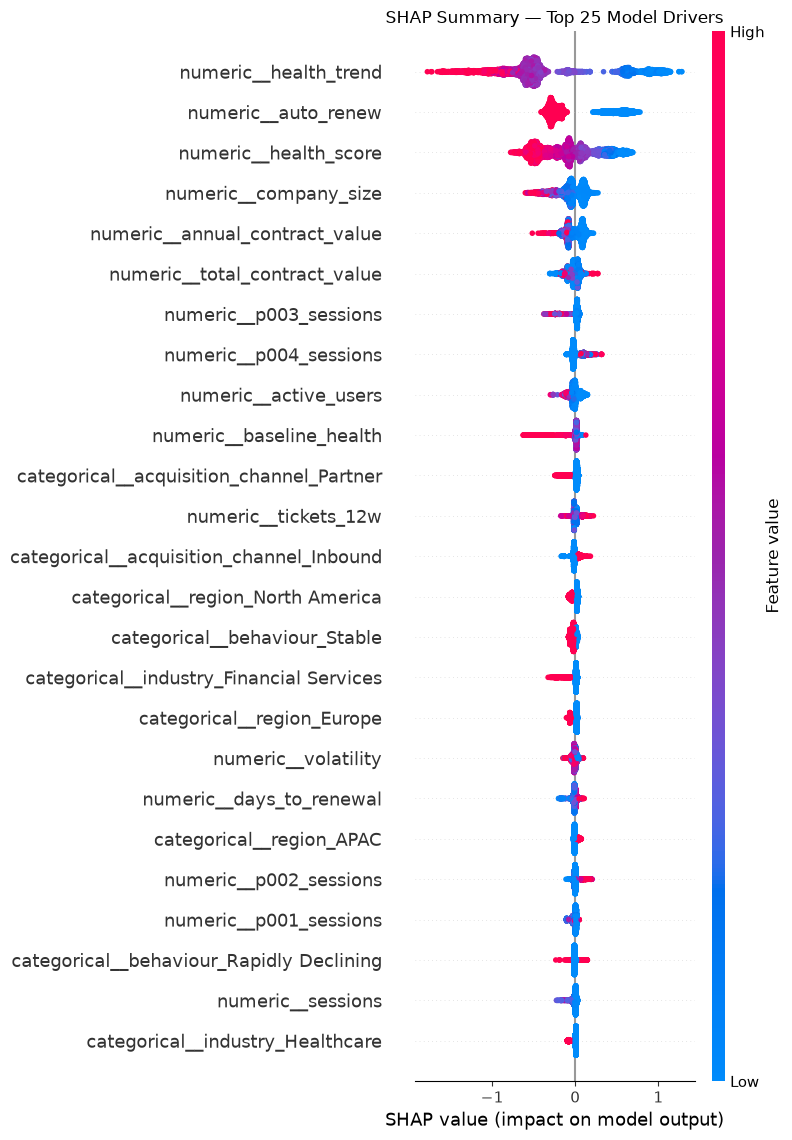

In [104]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_val_shap,
    feature_names=xgb_feature_names,
    max_display=25,
    show=False
)

plt.title("SHAP Summary — Top 25 Model Drivers")
plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# SHAP DIRECTION CHECK — TOP NUMERIC FEATURES
# ============================================================

# Create a dataframe containing the transformed features
X_shap_df = pd.DataFrame(
    X_val_shap,
    columns=xgb_feature_names
)

# SHAP values dataframe
shap_df = pd.DataFrame(
    shap_values,
    columns=xgb_feature_names
)

# Features we particularly want to investigate
features_to_check = [
    "numeric__health_trend",
    "numeric__auto_renew",
    "numeric__health_score",
    "numeric__company_size",
    "numeric__annual_contract_value",
    "numeric__total_contract_value",
    "numeric__p003_sessions",
    "numeric__p004_sessions",
    "numeric__active_users",
    "numeric__tickets_12w",
    "numeric__days_to_renewal"
]

direction_results = []

for feature in features_to_check:
    feature_values = X_shap_df[feature]
    feature_shap = shap_df[feature]

    direction_results.append({
        "feature": feature,
        "mean_feature_value": feature_values.mean(),
        "mean_shap": feature_shap.mean(),
        "corr_value_shap": feature_values.corr(feature_shap),
        "mean_abs_shap": feature_shap.abs().mean()
    })

direction_results = (
    pd.DataFrame(direction_results)
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print(
    direction_results.round(4).to_string(index=False)
)

                       feature  mean_feature_value  mean_shap  corr_value_shap  mean_abs_shap
         numeric__health_trend             -0.0084    -0.3647          -0.9199         0.6724
           numeric__auto_renew              0.7602    -0.0705          -0.9741         0.3227
         numeric__health_score             71.9266    -0.1142          -0.9631         0.3007
         numeric__company_size           1496.6186    -0.0525          -0.5697         0.1236
numeric__annual_contract_value        4345801.3203    -0.0078          -0.5543         0.0836
 numeric__total_contract_value        7133321.8932    -0.0239          -0.0401         0.0542
        numeric__p003_sessions            380.2902    -0.0155          -0.5358         0.0531
        numeric__p004_sessions            237.4810     0.0111           0.3482         0.0460
         numeric__active_users            299.7914    -0.0159          -0.4821         0.0423
          numeric__tickets_12w              1.9668     0.009

<Figure size 800x500 with 0 Axes>

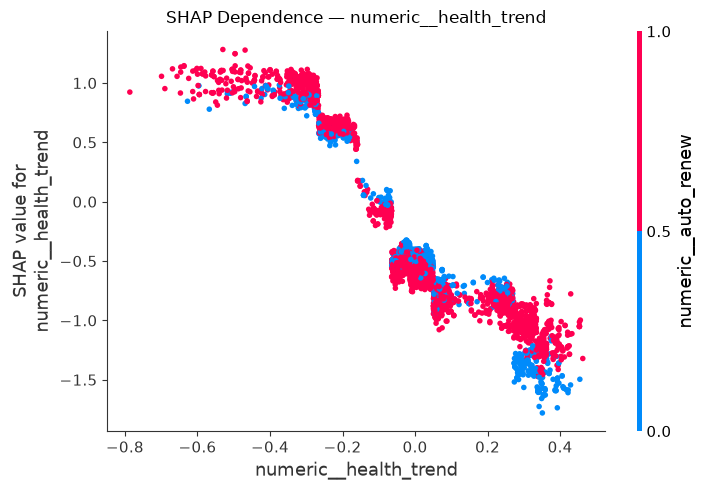

<Figure size 800x500 with 0 Axes>

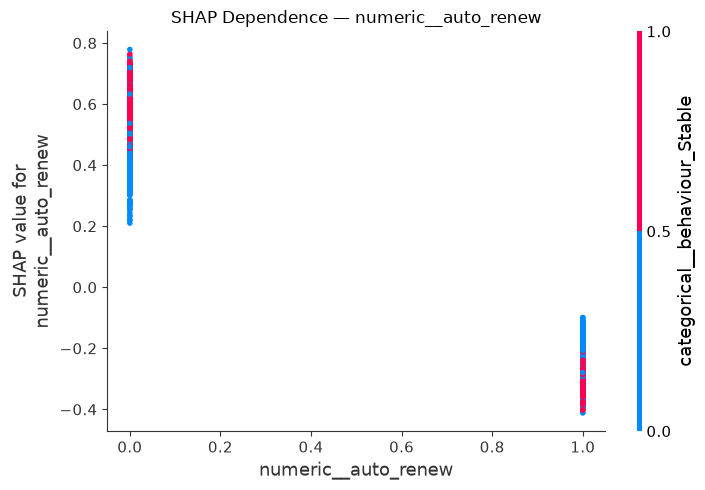

<Figure size 800x500 with 0 Axes>

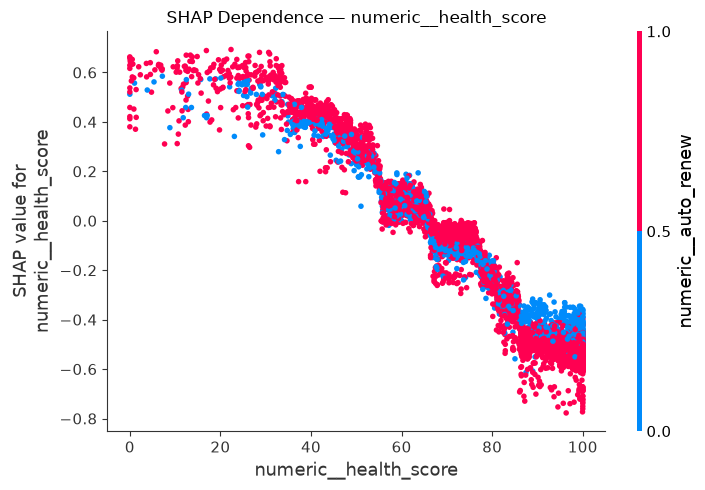

<Figure size 800x500 with 0 Axes>

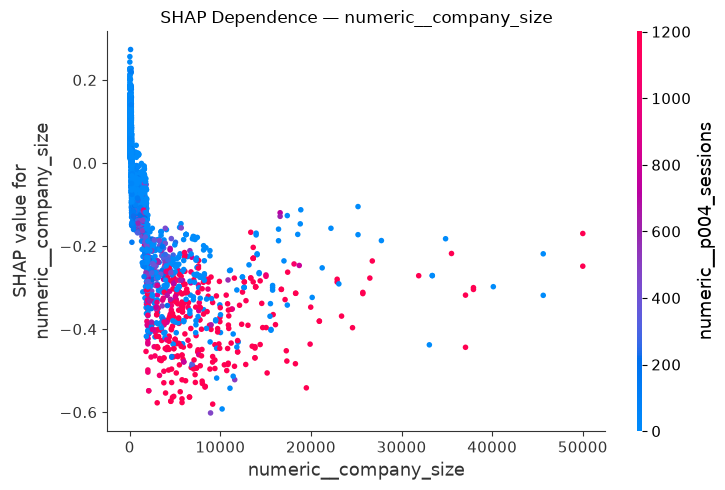

<Figure size 800x500 with 0 Axes>

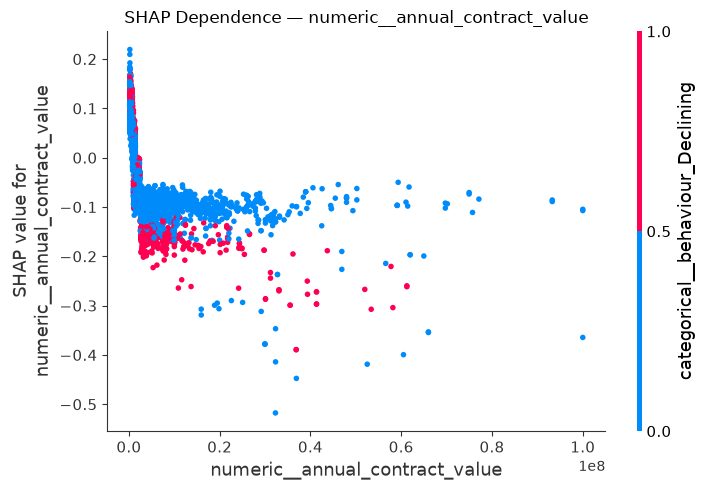

<Figure size 800x500 with 0 Axes>

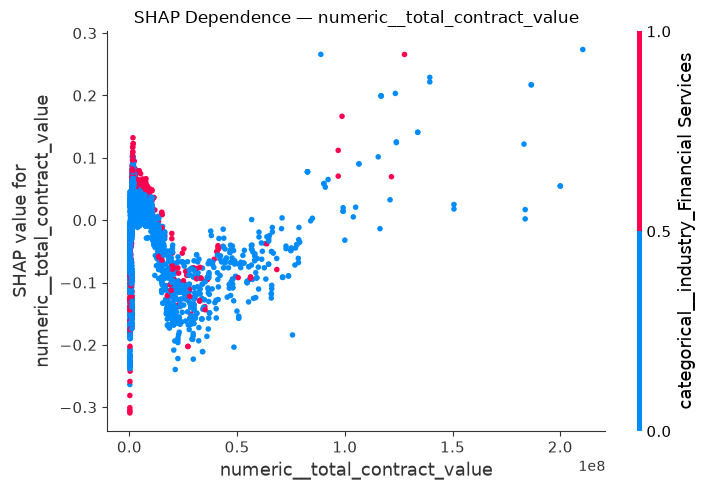

<Figure size 800x500 with 0 Axes>

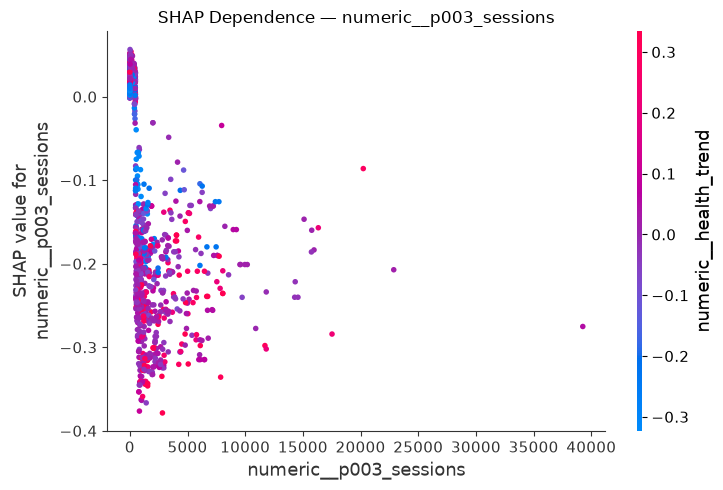

<Figure size 800x500 with 0 Axes>

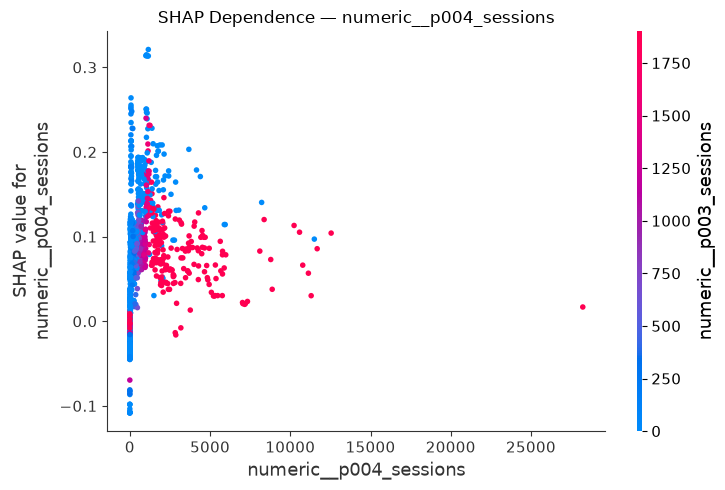

In [106]:
# ============================================================
# SHAP DEPENDENCE PLOTS — TOP FEATURES
# ============================================================

top_shap_features = [
    "numeric__health_trend",
    "numeric__auto_renew",
    "numeric__health_score",
    "numeric__company_size",
    "numeric__annual_contract_value",
    "numeric__total_contract_value",
    "numeric__p003_sessions",
    "numeric__p004_sessions"
]

for feature in top_shap_features:
    
    plt.figure(figsize=(8, 5))
    
    shap.dependence_plot(
        feature,
        shap_values,
        X_val_shap,
        feature_names=xgb_feature_names,
        interaction_index="auto",
        show=False
    )
    
    plt.title(f"SHAP Dependence — {feature}")
    plt.tight_layout()
    plt.show()

In [107]:
# ============================================================
# FIND CUSTOMER C04303 IN THE VALIDATION SET
# ============================================================

CUSTOMER_ID = "C04303"

customer_positions = np.flatnonzero(
    business_val["customer_id"].values == CUSTOMER_ID
)

print("Number of validation snapshots:", len(customer_positions))

if len(customer_positions) > 0:
    print(
        "Validation snapshot range:",
        business_val.iloc[customer_positions]["snapshot_date"].min(),
        "→",
        business_val.iloc[customer_positions]["snapshot_date"].max()
    )
    
    print("\nCustomer records:")
    print(
        business_val.iloc[customer_positions][
            [
                "customer_id",
                "snapshot_date",
                "churn_probability",
                "annual_contract_value",
                "revenue_at_risk",
                "health_score",
                "health_trend",
                "behaviour",
                "days_to_renewal"
            ]
        ].to_string(index=False)
    )
else:
    print("Customer not found in validation set.")

Number of validation snapshots: 3
Validation snapshot range: 2025-03-24 00:00:00 → 2025-04-07 00:00:00

Customer records:
customer_id snapshot_date  churn_probability  annual_contract_value  revenue_at_risk  health_score  health_trend         behaviour  days_to_renewal
     C04303    2025-03-24           0.137115            100000000.0     1.371152e+07          6.02       -0.4555 Rapidly Declining            359.0
     C04303    2025-03-31           0.099508            100000000.0     9.950835e+06          4.86       -0.4555 Rapidly Declining            352.0
     C04303    2025-04-07           0.098443            100000000.0     9.844275e+06          4.78       -0.4555 Rapidly Declining            345.0


In [108]:
# ============================================================
# INDIVIDUAL SHAP EXPLANATION — C04303
# ============================================================

CUSTOMER_ID = "C04303"

# Find all validation positions for this customer
customer_positions = np.flatnonzero(
    business_val["customer_id"].values == CUSTOMER_ID
)

# Select the latest validation snapshot
latest_position = customer_positions[
    np.argmax(
        business_val.iloc[customer_positions]["snapshot_date"].values
    )
]

# Original customer record
customer_record = business_val.iloc[latest_position]

# Corresponding transformed XGBoost row
X_customer_shap = X_val_xgb[latest_position:latest_position + 1]

# Calculate SHAP values
customer_shap_values = shap_explainer.shap_values(
    X_customer_shap
)[0]

# Create readable explanation table
customer_shap_df = pd.DataFrame({
    "feature": xgb_feature_names,
    "shap_value": customer_shap_values,
    "abs_shap": np.abs(customer_shap_values)
})

# Rank by absolute contribution
customer_shap_df = (
    customer_shap_df
    .sort_values("abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 90)
print(f"SHAP EXPLANATION — {CUSTOMER_ID}")
print("=" * 90)

print("\nCustomer state:")
print(f"Snapshot date:       {customer_record['snapshot_date'].date()}")
print(f"Churn probability:   {customer_record['churn_probability']:.2%}")
print(f"ACV:                 ₹{customer_record['annual_contract_value']:,.0f}")
print(f"Revenue at Risk:     ₹{customer_record['revenue_at_risk']:,.0f}")
print(f"Health score:        {customer_record['health_score']:.2f}")
print(f"Health trend:        {customer_record['health_trend']:.4f}")
print(f"Behaviour:           {customer_record['behaviour']}")
print(f"Days to renewal:     {customer_record['days_to_renewal']:.0f}")

print("\nTOP 15 SHAP DRIVERS:")
print("-" * 90)
print(
    customer_shap_df
    .head(15)
    [["feature", "shap_value", "abs_shap"]]
    .round(5)
    .to_string(index=False)
)

SHAP EXPLANATION — C04303

Customer state:
Snapshot date:       2025-04-07
Churn probability:   9.84%
ACV:                 ₹100,000,000
Revenue at Risk:     ₹9,844,275
Health score:        4.78
Health trend:        -0.4555
Behaviour:           Rapidly Declining
Days to renewal:     345

TOP 15 SHAP DRIVERS:
------------------------------------------------------------------------------------------
                                 feature  shap_value  abs_shap
                   numeric__health_trend     0.92624   0.92624
                   numeric__health_score     0.52035   0.52035
          numeric__annual_contract_value    -0.36452   0.36452
                   numeric__company_size    -0.27671   0.27671
categorical__acquisition_channel_Partner    -0.17623   0.17623
                     numeric__auto_renew    -0.16489   0.16489
categorical__behaviour_Rapidly Declining     0.09854   0.09854
                  numeric__p005_sessions    -0.06784   0.06784
                   numeric__activ

In [109]:
# ============================================================
# SHAP ADDITIVITY CHECK — C04303
# ============================================================

# SHAP expected/base value
base_value = shap_explainer.expected_value

# For binary classification, expected_value can occasionally
# be returned as an array depending on the SHAP/XGBoost version.
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).flatten()[0]

# SHAP reconstructed raw model output
shap_reconstructed_output = (
    base_value + customer_shap_values.sum()
)

# Actual XGBoost raw margin
actual_raw_output = xgb_regularized.predict(
    X_customer_shap,
    output_margin=True
)[0]

print("SHAP base value:          ", base_value)
print("Sum of SHAP values:       ", customer_shap_values.sum())
print("SHAP reconstructed output:", shap_reconstructed_output)
print("Actual XGBoost output:    ", actual_raw_output)
print("Absolute difference:      ",
      abs(shap_reconstructed_output - actual_raw_output))

SHAP base value:           0.006735283
Sum of SHAP values:        0.3727731
SHAP reconstructed output: 0.3795084
Actual XGBoost output:     0.3795085
Absolute difference:       8.940697e-08


In [110]:
# ============================================================
# RETAIN-AI — REUSABLE CUSTOMER SHAP EXPLANATION
# ============================================================

import numpy as np
import pandas as pd


# Original categorical model features
SHAP_CATEGORICAL_FEATURES = [
    "industry",
    "region",
    "segment",
    "acquisition_channel",
    "behaviour",
    "contract_type"
]


def clean_shap_feature_name(feature_name):
    """
    Convert transformed preprocessing names into
    business-readable feature names.
    """

    # Numeric feature
    if feature_name.startswith("numeric__"):
        clean_name = feature_name.replace("numeric__", "", 1)
        return clean_name.replace("_", " ").title()

    # One-hot categorical feature
    if feature_name.startswith("categorical__"):
        clean_name = feature_name.replace("categorical__", "", 1)

        for categorical_feature in SHAP_CATEGORICAL_FEATURES:
            prefix = categorical_feature + "_"

            if clean_name.startswith(prefix):
                category_value = clean_name[len(prefix):]

                return (
                    f"{categorical_feature.replace('_', ' ').title()}"
                    f": {category_value}"
                )

        return clean_name.replace("_", " ").title()

    return feature_name.replace("_", " ").title()


def get_original_feature_name(transformed_feature):
    """
    Map a transformed feature back to its original feature
    in the feature store.
    """

    if transformed_feature.startswith("numeric__"):
        return transformed_feature.replace("numeric__", "", 1)

    if transformed_feature.startswith("categorical__"):
        clean_name = transformed_feature.replace(
            "categorical__", "", 1
        )

        for categorical_feature in SHAP_CATEGORICAL_FEATURES:
            prefix = categorical_feature + "_"

            if clean_name.startswith(prefix):
                return categorical_feature

    return transformed_feature


def explain_customer(
    customer_id,
    top_n=5,
    verbose=True
):
    """
    Generate a reusable SHAP explanation for the
    latest validation snapshot of a customer.

    Parameters
    ----------
    customer_id : str
        Customer to explain.

    top_n : int
        Number of positive and negative drivers to return.

    verbose : bool
        Whether to print a formatted explanation.

    Returns
    -------
    dict
        Customer state and SHAP explanations.
    """

    # --------------------------------------------------------
    # 1. Locate customer in validation/business dataset
    # --------------------------------------------------------

    customer_positions = np.flatnonzero(
        business_val["customer_id"].values == customer_id
    )

    if len(customer_positions) == 0:
        raise ValueError(
            f"Customer {customer_id} was not found in validation data."
        )

    # --------------------------------------------------------
    # 2. Select latest validation snapshot
    # --------------------------------------------------------

    customer_dates = business_val.iloc[
        customer_positions
    ]["snapshot_date"].values

    latest_position = customer_positions[
        np.argmax(customer_dates)
    ]

    customer_record = business_val.iloc[latest_position]

    # --------------------------------------------------------
    # 3. Get exact transformed XGBoost row
    # --------------------------------------------------------

    X_customer = X_val_xgb[
        latest_position:latest_position + 1
    ]

    # --------------------------------------------------------
    # 4. Calculate SHAP values
    # --------------------------------------------------------

    customer_shap = shap_explainer.shap_values(
        X_customer
    )[0]

    # --------------------------------------------------------
    # 5. Build SHAP dataframe
    # --------------------------------------------------------

    explanation = pd.DataFrame({
        "transformed_feature": xgb_feature_names,
        "shap_value": customer_shap
    })

    explanation["abs_shap"] = (
        explanation["shap_value"].abs()
    )

    explanation["feature"] = (
        explanation["transformed_feature"]
        .apply(clean_shap_feature_name)
    )

    explanation["original_feature"] = (
        explanation["transformed_feature"]
        .apply(get_original_feature_name)
    )

    # --------------------------------------------------------
    # 6. Add actual customer feature values
    # --------------------------------------------------------

    actual_values = []

    for _, row in explanation.iterrows():

        original_feature = row["original_feature"]

        if original_feature in customer_record.index:
            actual_values.append(
                customer_record[original_feature]
            )
        else:
            actual_values.append(np.nan)

    explanation["actual_value"] = actual_values

    # --------------------------------------------------------
    # 7. Positive and negative drivers
    # --------------------------------------------------------

    positive_drivers = (
        explanation[
            explanation["shap_value"] > 0
        ]
        .sort_values(
            "shap_value",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    negative_drivers = (
        explanation[
            explanation["shap_value"] < 0
        ]
        .sort_values(
            "shap_value",
            ascending=True
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 8. Customer state
    # --------------------------------------------------------

    customer_state = {
        "customer_id": customer_record["customer_id"],
        "snapshot_date": customer_record["snapshot_date"],
        "churn_probability": customer_record[
            "churn_probability"
        ],
        "annual_contract_value": customer_record[
            "annual_contract_value"
        ],
        "revenue_at_risk": customer_record[
            "revenue_at_risk"
        ],
        "health_score": customer_record[
            "health_score"
        ],
        "health_trend": customer_record[
            "health_trend"
        ],
        "behaviour": customer_record[
            "behaviour"
        ],
        "days_to_renewal": customer_record[
            "days_to_renewal"
        ]
    }

    # --------------------------------------------------------
    # 9. Print human-readable result
    # --------------------------------------------------------

    if verbose:

        print("=" * 90)
        print(
            f"RETAIN-AI CUSTOMER EXPLANATION — {customer_id}"
        )
        print("=" * 90)

        print("\nCUSTOMER STATE")
        print("-" * 90)

        print(
            f"Snapshot date:       "
            f"{customer_state['snapshot_date'].date()}"
        )

        print(
            f"Churn probability:   "
            f"{customer_state['churn_probability']:.2%}"
        )

        print(
            f"Annual contract:     "
            f"₹{customer_state['annual_contract_value']:,.0f}"
        )

        print(
            f"Revenue at Risk:     "
            f"₹{customer_state['revenue_at_risk']:,.0f}"
        )

        print(
            f"Health score:        "
            f"{customer_state['health_score']:.2f}"
        )

        print(
            f"Health trend:        "
            f"{customer_state['health_trend']:.4f}"
        )

        print(
            f"Behaviour:           "
            f"{customer_state['behaviour']}"
        )

        print(
            f"Days to renewal:     "
            f"{customer_state['days_to_renewal']:.0f}"
        )

        print("\nTOP RISK DRIVERS")
        print("-" * 90)

        for _, row in positive_drivers.iterrows():

            print(
                f"🔴 {row['feature']:<35} "
                f"Value: {str(row['actual_value']):<15} "
                f"SHAP: +{row['shap_value']:.4f}"
            )

        print("\nTOP PROTECTIVE DRIVERS")
        print("-" * 90)

        for _, row in negative_drivers.iterrows():

            print(
                f"🟢 {row['feature']:<35} "
                f"Value: {str(row['actual_value']):<15} "
                f"SHAP: {row['shap_value']:.4f}"
            )

    return {
        "customer_state": customer_state,
        "positive_drivers": positive_drivers,
        "negative_drivers": negative_drivers,
        "all_shap_values": explanation
    }


print("✓ Customer SHAP explanation function created.")

✓ Customer SHAP explanation function created.


In [111]:
c04303_explanation = explain_customer(
    "C04303",
    top_n=5
)

RETAIN-AI CUSTOMER EXPLANATION — C04303

CUSTOMER STATE
------------------------------------------------------------------------------------------
Snapshot date:       2025-04-07
Churn probability:   9.84%
Annual contract:     ₹100,000,000
Revenue at Risk:     ₹9,844,275
Health score:        4.78
Health trend:        -0.4555
Behaviour:           Rapidly Declining
Days to renewal:     345

TOP RISK DRIVERS
------------------------------------------------------------------------------------------
🔴 Health Trend                        Value: -0.4555         SHAP: +0.9262
🔴 Health Score                        Value: 4.78            SHAP: +0.5203
🔴 Behaviour: Rapidly Declining        Value: Rapidly Declining SHAP: +0.0985
🔴 Days To Renewal                     Value: 345.0           SHAP: +0.0485
🔴 Features Used                       Value: 2               SHAP: +0.0388

TOP PROTECTIVE DRIVERS
------------------------------------------------------------------------------------------
🟢 Annual

In [112]:
# ============================================================
# INSPECT BUSINESS SIGNALS — C04303
# ============================================================

customer = c04303_explanation["customer_state"]

customer_id = customer["customer_id"]

customer_position = np.flatnonzero(
    business_val["customer_id"].values == customer_id
)

latest_position = customer_position[
    np.argmax(
        business_val.iloc[customer_position]["snapshot_date"].values
    )
]

c04303_row = business_val.iloc[latest_position]

signals_to_inspect = [
    "health_score",
    "health_trend",
    "behaviour",
    "active_users",
    "active_users_change_4w",
    "active_users_change_12w",
    "usage_minutes",
    "usage_minutes_change_12w",
    "features_used",
    "features_used_change_12w",
    "tickets_12w",
    "escalations_12w",
    "reopens_12w",
    "critical_tickets_12w",
    "high_priority_tickets_12w",
    "avg_csat_12w",
    "avg_resolution_hours_12w",
    "high_support_burden_12w",
    "high_escalation_12w",
    "low_csat_12w",
    "slow_resolution_12w",
    "days_to_renewal",
    "renewal_within_30d",
    "renewal_within_90d",
    "renewal_within_180d"
]

print("=" * 90)
print(f"BUSINESS SIGNALS — {customer_id}")
print("=" * 90)

for feature in signals_to_inspect:
    if feature in c04303_row.index:
        print(
            f"{feature:<35}: {c04303_row[feature]}"
        )

BUSINESS SIGNALS — C04303
health_score                       : 4.78
health_trend                       : -0.4555
behaviour                          : Rapidly Declining
active_users                       : 166
active_users_change_4w             : 166.0
active_users_change_12w            : 166.0
usage_minutes                      : 9535
usage_minutes_change_12w           : 9535.0
features_used                      : 2
features_used_change_12w           : 2.0
tickets_12w                        : 0.0
escalations_12w                    : 0.0
reopens_12w                        : 0.0
critical_tickets_12w               : 0.0
high_priority_tickets_12w          : 0.0
avg_csat_12w                       : nan
avg_resolution_hours_12w           : nan
high_support_burden_12w            : 0
high_escalation_12w                : 0
low_csat_12w                       : 0
slow_resolution_12w                : 0
days_to_renewal                    : 345.0
renewal_within_30d                 : 0
renewal_within

In [113]:
# ============================================================
# RETAIN-AI — BUSINESS SIGNAL DISTRIBUTIONS
# ============================================================

business_signal_features = [
    "health_score",
    "health_trend",
    "active_users_change_4w",
    "active_users_change_12w",
    "sessions_change_12w",
    "usage_minutes_change_12w",
    "features_used_change_12w",
    "active_users_pct_change_12w",
    "sessions_pct_change_12w",
    "usage_minutes_pct_change_12w",
    "features_used_pct_change_12w",
    "tickets_12w",
    "escalations_12w",
    "reopens_12w",
    "critical_tickets_12w",
    "high_priority_tickets_12w",
    "avg_csat_12w",
    "avg_resolution_hours_12w",
    "days_to_renewal",
    "annual_contract_value",
    "revenue_at_risk"
]

available_signals = [
    f for f in business_signal_features
    if f in current_risk.columns
]

business_signal_summary = (
    current_risk[available_signals]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

print("=" * 110)
print("BUSINESS SIGNAL DISTRIBUTIONS — CURRENT RISK")
print("=" * 110)

print(
    business_signal_summary.round(4).to_string(index=False)
)

BUSINESS SIGNAL DISTRIBUTIONS — CURRENT RISK
                     feature  count         mean          std          min         10%         25%          50%          75%          90%          95%          max
                health_score 7243.0      71.2829      22.2656       0.0000     40.1700     58.2250      73.5900      89.1650 9.923000e+01 1.000000e+02 1.000000e+02
                health_trend 7243.0      -0.0137       0.1908      -0.7865     -0.2701     -0.0620      -0.0050       0.0415 2.824000e-01 3.294000e-01 4.778000e-01
      active_users_change_4w 7243.0      22.9985     230.0813    -678.0000    -10.0000     -1.0000       0.0000       3.0000 2.500000e+01 6.500000e+01 8.227000e+03
     active_users_change_12w 7243.0      68.7368     390.2990   -1133.0000     -7.0000      0.0000       2.0000      18.0000 1.066000e+02 3.019000e+02 1.149300e+04
         sessions_change_12w 7243.0     504.7471    3238.4015  -11636.0000    -68.0000    -10.0000      11.0000     105.0000 6.588000e+

In [114]:
# ============================================================
# USAGE DECLINE FLAGS — CURRENT RISK
# ============================================================

usage_flag_features = [
    "usage_decline_4w_flag",
    "usage_decline_12w_flag",
    "severe_usage_decline_12w_flag"
]

for feature in usage_flag_features:
    print(f"\n{feature}")
    print("-" * 50)
    print(
        current_risk[feature]
        .value_counts(dropna=False)
        .sort_index()
    )
    print(
        "Share flagged:",
        current_risk[feature].mean()
    )


usage_decline_4w_flag
--------------------------------------------------
usage_decline_4w_flag
0    5932
1    1311
Name: count, dtype: int64
Share flagged: 0.18100234709374569

usage_decline_12w_flag
--------------------------------------------------
usage_decline_12w_flag
0    6860
1     383
Name: count, dtype: int64
Share flagged: 0.05287864144691426

severe_usage_decline_12w_flag
--------------------------------------------------
severe_usage_decline_12w_flag
0    7140
1     103
Name: count, dtype: int64
Share flagged: 0.014220626812094435


In [120]:
# ============================================================
# RETAIN-AI — BUSINESS DECISION ENGINE
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# BUSINESS ASSUMPTIONS
# ------------------------------------------------------------

INTERVENTION_SUCCESS_RATE = 0.30
INTERVENTION_COST = 25_000

DEFAULT_INTERVENTION_CAPACITY = 0.10


# ------------------------------------------------------------
# RISK TIERS
# ------------------------------------------------------------

def assign_risk_tier(probability):
    """
    Assign operational churn-risk tier.
    """

    if probability < 0.05:
        return "Low"
    elif probability < 0.10:
        return "Moderate"
    elif probability < 0.20:
        return "High"
    else:
        return "Critical"


# ------------------------------------------------------------
# FINANCIAL EXPOSURE TIERS
# ------------------------------------------------------------

def assign_exposure_tier(value, p50, p75, p90):
    """
    Assign financial exposure tier using portfolio
    percentiles.
    """

    if value < p50:
        return "Low"
    elif value < p75:
        return "Moderate"
    elif value < p90:
        return "High"
    else:
        return "Critical"


# ------------------------------------------------------------
# RENEWAL URGENCY
# ------------------------------------------------------------

def assign_renewal_urgency(days):
    """
    Assign operational renewal urgency.
    """

    if days <= 30:
        return "Critical"
    elif days <= 90:
        return "High"
    elif days <= 180:
        return "Moderate"
    elif days <= 365:
        return "Low"
    else:
        return "Very Low"


# ------------------------------------------------------------
# HEALTH SIGNAL
# ------------------------------------------------------------

def assign_health_signal(
    health_score,
    health_trend,
    behaviour
):
    """
    Identify the strongest account-health condition.
    """

    if (
        health_score < 40
        or health_trend < -0.20
        or behaviour == "Rapidly Declining"
    ):
        return "Critical deterioration"

    elif (
        health_score < 60
        or health_trend < -0.05
        or behaviour == "Declining"
    ):
        return "Deteriorating"

    elif health_score >= 75 and health_trend > 0.05:
        return "Healthy / Improving"

    else:
        return "Stable"


# ------------------------------------------------------------
# USAGE SIGNAL
# ------------------------------------------------------------

def assign_usage_signal(row):
    """
    Identify the strongest product-engagement condition.
    """

    if row["severe_usage_decline_12w_flag"] == 1:
        return "Severe persistent usage decline"

    elif row["usage_decline_12w_flag"] == 1:
        return "Persistent usage decline"

    elif row["usage_decline_4w_flag"] == 1:
        return "Recent usage decline"

    else:
        return "No significant usage decline"


# ------------------------------------------------------------
# SUPPORT SIGNAL
# ------------------------------------------------------------

def assign_support_signal(row):
    """
    Identify customer-support / experience condition.
    """

    if (
        row["high_escalation_12w"] == 1
        or row["high_support_burden_12w"] == 1
    ):
        return "High support burden"

    elif (
        row["low_csat_12w"] == 1
        or row["slow_resolution_12w"] == 1
    ):
        return "Customer experience concern"

    else:
        return "No significant support concern"


# ------------------------------------------------------------
# INTERVENTION RECOMMENDATIONS
# ------------------------------------------------------------

def generate_interventions(row):
    """
    Generate evidence-based intervention themes.

    These recommendations are based on observable business
    signals, not SHAP values alone.
    """

    interventions = []

    # Health
    if (
        row["health_score"] < 40
        or row["health_trend"] < -0.20
        or row["behaviour"] == "Rapidly Declining"
    ):
        interventions.append(
            "Account Health / Customer Success Intervention"
        )

    elif (
        row["health_score"] < 60
        or row["health_trend"] < -0.05
        or row["behaviour"] == "Declining"
    ):
        interventions.append(
            "Customer Success Monitoring"
        )

    # Usage / engagement
    if row["severe_usage_decline_12w_flag"] == 1:
        interventions.append(
            "Urgent Product Adoption Intervention"
        )

    elif row["usage_decline_12w_flag"] == 1:
        interventions.append(
            "Product Adoption / Engagement Intervention"
        )

    elif row["usage_decline_4w_flag"] == 1:
        interventions.append(
            "Early Engagement Warning"
        )

    # Support
    if (
        row["high_support_burden_12w"] == 1
        or row["high_escalation_12w"] == 1
    ):
        interventions.append(
            "Technical / Customer Experience Escalation"
        )

    elif (
        row["low_csat_12w"] == 1
        or row["slow_resolution_12w"] == 1
    ):
        interventions.append(
            "Customer Experience Review"
        )

    # Renewal
    if row["days_to_renewal"] <= 30:
        interventions.append(
            "Immediate Renewal Engagement"
        )

    elif row["days_to_renewal"] <= 90:
        interventions.append(
            "Renewal Engagement"
        )

    elif (
        row["days_to_renewal"] <= 180
        and row["churn_probability"] >= 0.10
    ):
        interventions.append(
            "Proactive Renewal Planning"
        )

    # Fallback
    if len(interventions) == 0:
        interventions.append(
            "Monitor"
        )

    return interventions


# ------------------------------------------------------------
# APPLY DECISION ENGINE
# ------------------------------------------------------------

def build_decision_engine(
    current_risk,
    intervention_success_rate=INTERVENTION_SUCCESS_RATE,
    intervention_cost=INTERVENTION_COST,
    intervention_capacity=DEFAULT_INTERVENTION_CAPACITY
):
    """
    Build the complete Retain-AI business decision dataset.
    """

    df = current_risk.copy()

    # --------------------------------------------------------
    # Risk
    # --------------------------------------------------------

    df["risk_tier"] = df[
        "churn_probability"
    ].apply(assign_risk_tier)

    # --------------------------------------------------------
    # Financial economics
    # --------------------------------------------------------

    df["revenue_at_risk"] = (
        df["churn_probability"]
        * df["annual_contract_value"]
    )

    df["expected_save_value"] = (
        df["revenue_at_risk"]
        * intervention_success_rate
    )

    df["intervention_cost"] = intervention_cost

    df["net_expected_value"] = (
        df["expected_save_value"]
        - df["intervention_cost"]
    )

    # --------------------------------------------------------
    # Financial exposure
    # --------------------------------------------------------

    p50 = df["revenue_at_risk"].quantile(0.50)
    p75 = df["revenue_at_risk"].quantile(0.75)
    p90 = df["revenue_at_risk"].quantile(0.90)

    df["exposure_tier"] = df[
        "revenue_at_risk"
    ].apply(
        lambda x: assign_exposure_tier(
            x,
            p50,
            p75,
            p90
        )
    )

    # --------------------------------------------------------
    # Renewal urgency
    # --------------------------------------------------------

    df["renewal_urgency"] = df[
        "days_to_renewal"
    ].apply(assign_renewal_urgency)

    # --------------------------------------------------------
    # Health
    # --------------------------------------------------------

    df["health_signal"] = df.apply(
        lambda row: assign_health_signal(
            row["health_score"],
            row["health_trend"],
            row["behaviour"]
        ),
        axis=1
    )

    # --------------------------------------------------------
    # Usage
    # --------------------------------------------------------

    df["usage_signal"] = df.apply(
        assign_usage_signal,
        axis=1
    )

    # --------------------------------------------------------
    # Support
    # --------------------------------------------------------

    df["support_signal"] = df.apply(
        assign_support_signal,
        axis=1
    )

    # --------------------------------------------------------
    # Intervention recommendations
    # --------------------------------------------------------

    df["recommended_interventions"] = df.apply(
        generate_interventions,
        axis=1
    )

    # Human-readable intervention string
    df["recommended_action"] = df[
        "recommended_interventions"
    ].apply(
        lambda x: " | ".join(x)
    )

    # --------------------------------------------------------
    # Intervention eligibility
    # --------------------------------------------------------

    df["economically_viable"] = (
        df["net_expected_value"] > 0
    )

    # --------------------------------------------------------
    # Priority ranking
    # --------------------------------------------------------

    df["priority_rank"] = (
        df["net_expected_value"]
        .rank(
            ascending=False,
            method="first"
        )
        .astype(int)
    )

    # --------------------------------------------------------
    # Capacity selection
    # --------------------------------------------------------

    capacity_count = max(
        1,
        int(
            np.floor(
                len(df)
                * intervention_capacity
            )
        )
    )

    eligible = df[
        df["economically_viable"]
    ].copy()

    eligible = eligible.sort_values(
        "net_expected_value",
        ascending=False
    )

    selected_ids = set(
        eligible.head(capacity_count)[
            "customer_id"
        ]
    )

    df["selected_for_intervention"] = (
        df["customer_id"]
        .isin(selected_ids)
    )

    # --------------------------------------------------------
    # Final ordering
    # --------------------------------------------------------

    df = df.sort_values(
        "priority_rank"
    ).reset_index(drop=True)

    return df


print("✓ Retain-AI decision engine created.")

✓ Retain-AI decision engine created.


In [121]:
# ============================================================
# RUN RETAIN-AI DECISION ENGINE
# ============================================================


decision_df = build_decision_engine(
    current_risk=current_risk,
    intervention_success_rate=0.30,
    intervention_cost=25_000,
    intervention_capacity=0.10
)

print("Decision dataset shape:", decision_df.shape)
print(
    "Selected for intervention:",
    decision_df["selected_for_intervention"].sum()
)
print(
    "Economically viable:",
    decision_df["economically_viable"].sum()
)

Decision dataset shape: (7243, 118)
Selected for intervention: 724
Economically viable: 2610


In [122]:
# ============================================================
# RETAIN-AI — INTERVENTION PORTFOLIO VALIDATION
# ============================================================

selected = decision_df[
    decision_df["selected_for_intervention"]
].copy()

# Portfolio metrics
total_customers = len(decision_df)
selected_customers = len(selected)

total_revenue_at_risk = selected[
    "revenue_at_risk"
].sum()

total_expected_save = selected[
    "expected_save_value"
].sum()

total_intervention_cost = selected[
    "intervention_cost"
].sum()

total_net_expected_value = selected[
    "net_expected_value"
].sum()

roi = (
    total_expected_save
    / total_intervention_cost
)

risk_coverage = (
    total_revenue_at_risk
    / decision_df["revenue_at_risk"].sum()
)

customer_coverage = (
    selected_customers
    / total_customers
)

print("=" * 65)
print("RETAIN-AI INTERVENTION PORTFOLIO")
print("=" * 65)

print(f"Total customers:              {total_customers:,}")
print(f"Selected customers:            {selected_customers:,}")
print(f"Customer coverage:             {customer_coverage:.2%}")
print()

print(
    f"Revenue at Risk covered:       "
    f"₹{total_revenue_at_risk:,.0f}"
)

print(
    f"Expected Save Value:           "
    f"₹{total_expected_save:,.0f}"
)

print(
    f"Intervention Cost:             "
    f"₹{total_intervention_cost:,.0f}"
)

print(
    f"Net Expected Value:            "
    f"₹{total_net_expected_value:,.0f}"
)

print(
    f"Expected ROI:                  "
    f"{roi:.2f}x"
)

print(
    f"Revenue-at-Risk coverage:      "
    f"{risk_coverage:.2%}"
)

print("=" * 65)

RETAIN-AI INTERVENTION PORTFOLIO
Total customers:              7,243
Selected customers:            724
Customer coverage:             10.00%

Revenue at Risk covered:       ₹760,089,161
Expected Save Value:           ₹228,026,748
Intervention Cost:             ₹18,100,000
Net Expected Value:            ₹209,926,748
Expected ROI:                  12.60x
Revenue-at-Risk coverage:      62.48%


In [124]:
# ============================================================
# SELECTED PORTFOLIO — SEGMENT ANALYSIS
# ============================================================

segment_portfolio = (
    selected
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        revenue_at_risk=("revenue_at_risk", "sum"),
        expected_save=("expected_save_value", "sum"),
        intervention_cost=("intervention_cost", "sum"),
        net_expected_value=("net_expected_value", "sum"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_acv=("annual_contract_value", "mean")
    )
    .reset_index()
)

segment_portfolio["roi"] = (
    segment_portfolio["expected_save"]
    / segment_portfolio["intervention_cost"]
)

segment_portfolio["risk_share"] = (
    segment_portfolio["revenue_at_risk"]
    / segment_portfolio["revenue_at_risk"].sum()
)

segment_portfolio = segment_portfolio.sort_values(
    "revenue_at_risk",
    ascending=False
)

print(
    segment_portfolio.to_string(index=False)
)

   segment  customers  revenue_at_risk  expected_save  intervention_cost  net_expected_value  avg_churn_probability      avg_acv       roi  risk_share
Enterprise        423     5.334251e+08   1.600275e+08           10575000        1.494525e+08               0.059981 2.751516e+07 15.132628    0.701793
Mid-Market        289     2.219685e+08   6.659056e+07            7225000        5.936556e+07               0.155181 5.324129e+06  9.216686    0.292030
       SMB         12     4.695515e+06   1.408655e+06             300000        1.108655e+06               0.263703 1.484827e+06  4.695515    0.006178


In [125]:
# ============================================================
# TOP 20 SELECTED CUSTOMERS
# ============================================================

display_columns = [
    "priority_rank",
    "customer_id",
    "segment",
    "churn_probability",
    "risk_tier",
    "annual_contract_value",
    "revenue_at_risk",
    "expected_save_value",
    "net_expected_value",
    "days_to_renewal",
    "renewal_urgency",
    "health_signal",
    "usage_signal",
    "support_signal",
    "recommended_action"
]

display(
    selected[
        display_columns
    ].head(20)
)

,priority_rank,customer_id,segment,churn_probability,risk_tier,annual_contract_value,revenue_at_risk,expected_save_value,net_expected_value,days_to_renewal,renewal_urgency,health_signal,usage_signal,support_signal,recommended_action
0,1,C04303,Enterprise,0.098443,Moderate,1.000000e+08,9.844275e+06,2.953282e+06,2.928282e+06,345.0,Low,Critical deterioration,No significant usage decline,No significant support concern,Account Health / Customer Success Intervention
1,2,C14363,Enterprise,0.138597,High,6.897868e+07,9.560213e+06,2.868064e+06,2.843064e+06,543.0,Very Low,Critical deterioration,No significant usage decline,No significant support concern,Account Health / Customer Success Intervention
2,3,C06485,Enterprise,0.177886,High,5.079694e+07,9.036083e+06,2.710825e+06,2.685825e+06,877.0,Very Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...
3,4,C19505,Enterprise,0.147360,High,5.250542e+07,7.737196e+06,2.321159e+06,2.296159e+06,637.0,Very Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...
4,5,C00181,Enterprise,0.157202,High,3.689476e+07,5.799943e+06,1.739983e+06,1.714983e+06,296.0,Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...
5,6,C04785,Enterprise,0.130130,High,4.103873e+07,5.340369e+06,1.602111e+06,1.577111e+06,627.0,Very Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...
6,7,C02116,Enterprise,0.091076,Moderate,5.815673e+07,5.296686e+06,1.589006e+06,1.564006e+06,664.0,Very Low,Deteriorating,No significant usage decline,No significant support concern,Customer Success Monitoring
7,8,C01972,Enterprise,0.130247,High,3.997209e+07,5.206261e+06,1.561878e+06,1.536878e+06,948.0,Very Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...
8,9,C00012,Enterprise,0.151904,High,3.371142e+07,5.120893e+06,1.536268e+06,1.511268e+06,626.0,Very Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...
9,10,C19573,Enterprise,0.080196,Moderate,6.123865e+07,4.911068e+06,1.473320e+06,1.448320e+06,847.0,Very Low,Critical deterioration,No significant usage decline,High support burden,Account Health / Customer Success Intervention...


In [126]:
# ============================================================
# FIX FINANCIAL METRICS
# ============================================================

decision_df["expected_benefit_cost_ratio"] = (
    decision_df["expected_save_value"]
    / decision_df["intervention_cost"]
)

decision_df["expected_roi"] = (
    decision_df["net_expected_value"]
    / decision_df["intervention_cost"]
)

print("✓ Financial metrics updated")

print()
print(
    decision_df[
        [
            "customer_id",
            "revenue_at_risk",
            "expected_save_value",
            "intervention_cost",
            "net_expected_value",
            "expected_benefit_cost_ratio",
            "expected_roi"
        ]
    ].head(10).to_string(index=False)
)

✓ Financial metrics updated

customer_id  revenue_at_risk  expected_save_value  intervention_cost  net_expected_value  expected_benefit_cost_ratio  expected_roi
     C04303     9.844275e+06         2.953282e+06              25000        2.928282e+06                   118.131299    117.131299
     C14363     9.560213e+06         2.868064e+06              25000        2.843064e+06                   114.722555    113.722555
     C06485     9.036083e+06         2.710825e+06              25000        2.685825e+06                   108.432993    107.432993
     C19505     7.737196e+06         2.321159e+06              25000        2.296159e+06                    92.846354     91.846354
     C00181     5.799943e+06         1.739983e+06              25000        1.714983e+06                    69.599321     68.599321
     C04785     5.340369e+06         1.602111e+06              25000        1.577111e+06                    64.084424     63.084424
     C02116     5.296686e+06         1.589006e+

In [128]:
# ============================================================
# GENERATE FROZEN XGBOOST TEST PREDICTIONS
# ============================================================

# Generate test probabilities from the already-fitted
# calibrated XGBoost model.

test_prob = xgb_calibrated.predict_proba(
    X_test_xgb
)[:, 1]

print("✓ Test probabilities generated")
print("Length:", len(test_prob))
print("Expected:", len(y_test))
print(
    "Probability range:",
    f"{test_prob.min():.6f} → {test_prob.max():.6f}"
)
print(
    "Mean probability:",
    f"{test_prob.mean():.4%}"
)
print(
    "Actual positive rate:",
    f"{y_test.mean():.4%}"
)

✓ Test probabilities generated
Length: 90358
Expected: 90358
Probability range: 0.008089 → 0.309280
Mean probability: 5.1674%
Actual positive rate: 5.4926%


In [131]:
# ============================================================
# FINAL UNTOUCHED TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

test_brier = brier_score_loss(
    y_test,
    test_prob
)

print("=" * 65)
print("RETAIN-AI — FINAL TEST EVALUATION")
print("=" * 65)

print(f"Test ROC-AUC:      {test_roc_auc:.4f}")
print(f"Test PR-AUC:       {test_pr_auc:.4f}")
print(f"Test Brier Score:  {test_brier:.4f}")
print()

print(
    f"Actual positive rate:       "
    f"{y_test.mean():.4%}"
)

print(
    f"Mean predicted probability: "
    f"{test_prob.mean():.4%}"
)

print(
    f"Probability range:          "
    f"{test_prob.min():.6f} → {test_prob.max():.6f}"
)

print("=" * 65)

RETAIN-AI — FINAL TEST EVALUATION
Test ROC-AUC:      0.8082
Test PR-AUC:       0.2245
Test Brier Score:  0.0468

Actual positive rate:       5.4926%
Mean predicted probability: 5.1674%
Probability range:          0.008089 → 0.309280


In [132]:
# ============================================================
# TEST THRESHOLD PERFORMANCE
# ============================================================

test_thresholds = [
    0.05,
    0.10,
    0.13,
    0.15,
    0.20,
    0.25,
    0.30
]

test_threshold_results = []

for threshold in test_thresholds:

    pred = (
        test_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    flagged = pred.sum()

    test_threshold_results.append({
        "threshold": threshold,
        "flagged": flagged,
        "flagged_pct": flagged / len(y_test),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

test_threshold_df = pd.DataFrame(
    test_threshold_results
)

display(test_threshold_df)

,threshold,flagged,flagged_pct,precision,recall,f1
0,0.05,24418,0.270236,0.146245,0.719524,0.243082
1,0.10,14136,0.156444,0.204938,0.583720,0.303367
2,0.13,11354,0.125656,0.223798,0.511989,0.311454
3,0.15,9836,0.108856,0.234140,0.464034,0.311237
4,0.20,5529,0.061190,0.286309,0.318960,0.301754
5,0.25,1738,0.019235,0.330840,0.115857,0.171616
6,0.30,22,0.000243,0.318182,0.001410,0.002808


In [133]:
# ============================================================
# TEST TOP-K INTERVENTION PERFORMANCE
# ============================================================

def evaluate_top_k(
    y_true,
    probabilities,
    capacities=(0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25)
):

    results = []

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    total = len(y_true)
    total_churners = y_true.sum()

    ranking = np.argsort(
        probabilities
    )[::-1]

    for capacity in capacities:

        k = max(
            1,
            int(np.floor(total * capacity))
        )

        selected_idx = ranking[:k]

        churners_captured = y_true[
            selected_idx
        ].sum()

        precision = (
            churners_captured / k
        )

        recall = (
            churners_captured
            / total_churners
        )

        lift = (
            precision
            / y_true.mean()
        )

        results.append({
            "capacity": capacity,
            "customers_targeted": k,
            "churners_captured": int(
                churners_captured
            ),
            "precision": precision,
            "recall": recall,
            "lift": lift
        })

    return pd.DataFrame(results)


test_top_k = evaluate_top_k(
    y_true=y_test,
    probabilities=test_prob
)

display(test_top_k)

,capacity,customers_targeted,churners_captured,precision,recall,lift
0,0.01,903,336,0.372093,0.067701,6.774447
1,0.02,1807,596,0.329828,0.120089,6.004964
2,0.05,4517,1352,0.299314,0.272416,5.449403
3,0.10,9035,2158,0.238849,0.434818,4.348562
4,0.15,13553,2806,0.207039,0.565384,3.769420
5,0.20,18071,3213,0.177799,0.647391,3.237061
6,0.25,22589,3486,0.154323,0.702398,2.809653


In [134]:
# ============================================================
# RETAIN-AI — SAVE FROZEN MODEL ARTIFACTS
# ============================================================

from pathlib import Path
import joblib

# Project root
PROJECT_ROOT = Path.cwd()

# If notebook is not running from project root, adjust this path
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Save calibrated model
# ------------------------------------------------------------

joblib.dump(
    xgb_calibrated,
    MODELS_DIR / "xgb_calibrated.joblib"
)

# ------------------------------------------------------------
# Save XGBoost preprocessing pipeline
# ------------------------------------------------------------

joblib.dump(
    xgb_preprocessor,
    MODELS_DIR / "xgb_preprocessor.joblib"
)

# ------------------------------------------------------------
# Save underlying regularized XGBoost model
# ------------------------------------------------------------

joblib.dump(
    xgb_regularized,
    MODELS_DIR / "xgb_regularized.joblib"
)

# ------------------------------------------------------------
# Save business configuration
# ------------------------------------------------------------

business_config = {
    "intervention_success_rate": 0.30,
    "intervention_cost": 25000,
    "default_intervention_capacity": 0.10,
    "risk_tiers": {
        "low_max": 0.05,
        "moderate_max": 0.10,
        "high_max": 0.20
    },
    "renewal_urgency": {
        "critical_max_days": 30,
        "high_max_days": 90,
        "moderate_max_days": 180,
        "low_max_days": 365
    }
}

joblib.dump(
    business_config,
    MODELS_DIR / "business_config.joblib"
)

print("✓ Frozen model artifacts saved")
print()
for path in MODELS_DIR.iterdir():
    print(path.name, "—", f"{path.stat().st_size / 1024:.1f} KB")

✓ Frozen model artifacts saved

business_config.joblib — 0.3 KB
xgb_calibrated.joblib — 1419.8 KB
xgb_preprocessor.joblib — 10.9 KB
xgb_regularized.joblib — 240.1 KB


In [135]:
# ============================================================
# RETAIN-AI — MODEL ARTIFACT REPRODUCIBILITY TEST
# ============================================================

import joblib
import numpy as np

# Load the saved calibrated model
loaded_xgb_calibrated = joblib.load(
    MODELS_DIR / "xgb_calibrated.joblib"
)

# Generate predictions using the saved artifact
loaded_test_prob = (
    loaded_xgb_calibrated
    .predict_proba(X_test_xgb)[:, 1]
)

# Compare with the original notebook predictions
max_difference = np.max(
    np.abs(
        loaded_test_prob
        - test_prob
    )
)

mean_difference = np.mean(
    np.abs(
        loaded_test_prob
        - test_prob
    )
)

print("=" * 65)
print("MODEL REPRODUCIBILITY TEST")
print("=" * 65)

print(
    f"Original predictions:  {len(test_prob):,}"
)

print(
    f"Loaded predictions:    {len(loaded_test_prob):,}"
)

print(
    f"Maximum difference:    {max_difference:.12f}"
)

print(
    f"Mean absolute diff:     {mean_difference:.12f}"
)

if np.allclose(
    test_prob,
    loaded_test_prob,
    rtol=1e-10,
    atol=1e-12
):
    print()
    print("✓ REPRODUCIBILITY TEST PASSED")
    print("✓ Saved model reproduces notebook predictions")
else:
    print()
    print("✗ REPRODUCIBILITY TEST FAILED")

print("=" * 65)

MODEL REPRODUCIBILITY TEST
Original predictions:  90,358
Loaded predictions:    90,358
Maximum difference:    0.000000000000
Mean absolute diff:     0.000000000000

✓ REPRODUCIBILITY TEST PASSED
✓ Saved model reproduces notebook predictions


In [136]:
# ============================================================
# RETAIN-AI — MODEL METADATA
# ============================================================

import json

model_metadata = {
    "model_name": "Retain-AI Calibrated XGBoost",
    "model_type": "XGBClassifier + Sigmoid Calibration",
    "training_period": "2024-01-01 to 2024-10-28",
    "validation_period": "2025-02-03 to 2025-04-07",
    "test_period": "2025-07-14 to 2025-10-06",

    "validation": {
        "roc_auc": 0.8016,
        "pr_auc": 0.2466,
        "brier_score": 0.0467
    },

    "test": {
        "roc_auc": 0.8082,
        "pr_auc": 0.2245,
        "brier_score": 0.0468
    },

    "operating_point": {
        "default_capacity": 0.10,
        "validation_precision": 0.2451,
        "validation_recall": 0.4448,
        "validation_lift": 4.4488,
        "test_precision": 0.2388,
        "test_recall": 0.4348,
        "test_lift": 4.3486
    },

    "business_assumptions": {
        "intervention_success_rate": 0.30,
        "intervention_cost": 25000
    }
}

with open(
    MODELS_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        model_metadata,
        f,
        indent=4
    )

print("✓ Model metadata saved")

✓ Model metadata saved


In [139]:
from pathlib import Path
import os
import sys

print("Current working directory:")
print(Path.cwd())

print("\nPython executable:")
print(sys.executable)

print("\nCurrent directory contents:")
for item in Path.cwd().iterdir():
    print(" -", item.name)

Current working directory:
c:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI\notebooks

Python executable:
c:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI\.venv\Scripts\python.exe

Current directory contents:
 - 01_data_validation.ipynb
 - 02_generate_usage.ipynb
 - dataset_generation.ipynb
 - models


In [140]:
from pathlib import Path

project_root = Path(
    r"C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI"
)

print("Project exists:", project_root.exists())
print("src exists:", (project_root / "src").exists())
print("inference.py exists:", (project_root / "src" / "inference.py").exists())

Project exists: True
src exists: True
inference.py exists: True


In [141]:
import sys

project_root = r"C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(sys.path[0])

C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI


In [142]:
from src.inference import (
    load_model,
    load_preprocessor,
    run_inference
)

print("✓ src.inference imported successfully")

✓ src.inference imported successfully


In [146]:
# ============================================================
# PRODUCTION INFERENCE REPRODUCIBILITY TEST
# ============================================================

import sys
from pathlib import Path
import numpy as np

# Add project root to Python path if necessary
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.inference import (
    load_model,
    load_preprocessor,
    run_inference
)

# ------------------------------------------------------------
# Load production artifacts
# ------------------------------------------------------------

production_model = load_model()
production_preprocessor = load_preprocessor()

# ------------------------------------------------------------
# IMPORTANT:
# X_test contains the original 95 model features.
# ------------------------------------------------------------

production_test = run_inference(
    X_test,
    model=production_model,
    preprocessor=production_preprocessor
)

production_test_prob = (
    production_test["churn_probability"]
    .to_numpy()
)

# ------------------------------------------------------------
# Compare against the frozen notebook prediction
# ------------------------------------------------------------

max_difference = np.max(
    np.abs(
        production_test_prob
        - test_prob
    )
)

mean_difference = np.mean(
    np.abs(
        production_test_prob
        - test_prob
    )
)

print("=" * 65)
print("PRODUCTION INFERENCE REPRODUCIBILITY TEST")
print("=" * 65)

print(
    f"Original predictions:    {len(test_prob):,}"
)

print(
    f"Production predictions:  "
    f"{len(production_test_prob):,}"
)

print(
    f"Maximum difference:      "
    f"{max_difference:.12f}"
)

print(
    f"Mean absolute difference:"
    f" {mean_difference:.12f}"
)

if np.allclose(
    test_prob,
    production_test_prob,
    rtol=1e-10,
    atol=1e-12
):
    print()
    print("✓ PRODUCTION INFERENCE TEST PASSED")
    print("✓ Exact predictions reproduced")
else:
    print()
    print("✗ PRODUCTION INFERENCE TEST FAILED")

print("=" * 65)

PRODUCTION INFERENCE REPRODUCIBILITY TEST
Original predictions:    90,358
Production predictions:  90,358
Maximum difference:      0.000000000000
Mean absolute difference: 0.000000000000

✓ PRODUCTION INFERENCE TEST PASSED
✓ Exact predictions reproduced


In [147]:
# ============================================================
# SANITY CHECK — PRODUCTION INFERENCE
# ============================================================

sample = X_test.iloc[:5].copy()

sample_predictions = run_inference(
    sample,
    model=production_model,
    preprocessor=production_preprocessor
)

display(
    sample_predictions[
        ["customer_id", "churn_probability"]
    ]
)

KeyError: "['customer_id'] not in index"

In [148]:
# ============================================================
# TEST DATAFRAME WITH IDENTIFIERS
# ============================================================

test_snapshots = sorted(
    features["snapshot_date"].unique()
)[80:93]

test_inference_df = features[
    features["snapshot_date"].isin(test_snapshots)
].copy()

print("Shape:", test_inference_df.shape)
print(
    "Customers:",
    test_inference_df["customer_id"].nunique()
)
print(
    "Snapshots:",
    test_inference_df["snapshot_date"].nunique()
)

print(
    "\nDate range:",
    test_inference_df["snapshot_date"].min(),
    "→",
    test_inference_df["snapshot_date"].max()
)

Shape: (90358, 101)
Customers: 8321
Snapshots: 13

Date range: 2025-07-14 00:00:00 → 2025-10-06 00:00:00


In [149]:
# ============================================================
# CREATE PRODUCTION MODEL INPUT
# ============================================================

MODEL_EXCLUSIONS = [
    "customer_id",
    "contract_id",
    "snapshot_date",
    "churn_90d",
    "contract_active",
    "contract_age_days"
]

model_columns = [
    column
    for column in test_inference_df.columns
    if column not in MODEL_EXCLUSIONS
]

X_test_production = test_inference_df[
    model_columns
].copy()

print(
    "Production model input shape:",
    X_test_production.shape
)

Production model input shape: (90358, 95)


In [150]:
# ============================================================
# PRODUCTION INFERENCE WITH CUSTOMER IDENTIFIERS
# ============================================================

production_result = run_inference(
    test_inference_df.drop(
        columns=["churn_90d"]
    ),
    model=production_model,
    preprocessor=production_preprocessor
)

print(
    "Result shape:",
    production_result.shape
)

print(
    "\nRequired columns present:"
)

for column in [
    "customer_id",
    "snapshot_date",
    "churn_probability"
]:
    print(
        f"{column}:",
        column in production_result.columns
    )

display(
    production_result[
        [
            "customer_id",
            "snapshot_date",
            "churn_probability"
        ]
    ].head()
)

Result shape: (90358, 101)

Required columns present:
customer_id: True
snapshot_date: True
churn_probability: True


,customer_id,snapshot_date,churn_probability
42,C00001,2025-07-14,0.024359
43,C00001,2025-07-21,0.024634
44,C00001,2025-07-28,0.028761
45,C00001,2025-08-04,0.028811
46,C00001,2025-08-11,0.027821


In [151]:
# ============================================================
# FINAL PRODUCTION PREDICTION CHECK
# ============================================================

production_prob = (
    production_result[
        "churn_probability"
    ].to_numpy()
)

difference = np.abs(
    production_prob - test_prob
)

print()
print(
    "Maximum probability difference:",
    f"{difference.max():.12f}"
)

print(
    "Mean probability difference:",
    f"{difference.mean():.12f}"
)

assert np.allclose(
    production_prob,
    test_prob,
    rtol=1e-10,
    atol=1e-12
)

print()
print("✓ IDENTIFIER PRESERVATION TEST PASSED")
print("✓ PREDICTION REPRODUCIBILITY TEST PASSED")


Maximum probability difference: 0.000000000000
Mean probability difference: 0.000000000000

✓ IDENTIFIER PRESERVATION TEST PASSED
✓ PREDICTION REPRODUCIBILITY TEST PASSED


In [152]:
from src.decision_engine import (
    build_decision_engine
)

print("✓ Production decision engine imported")

✓ Production decision engine imported


In [153]:
# ============================================================
# PRODUCTION DECISION ENGINE TEST
# ============================================================

production_decision_df = build_decision_engine(
    predictions=current_risk,
    intervention_success_rate=0.30,
    intervention_cost=25_000,
    intervention_capacity=0.10
)

print(
    "Production decision dataset shape:",
    production_decision_df.shape
)

print(
    "Selected for intervention:",
    production_decision_df[
        "selected_for_intervention"
    ].sum()
)

print(
    "Economically viable:",
    production_decision_df[
        "economically_viable"
    ].sum()
)

Production decision dataset shape: (7243, 120)
Selected for intervention: 724
Economically viable: 2610


In [154]:
# ============================================================
# DECISION ENGINE REPRODUCIBILITY TEST
# ============================================================

comparison_columns = [
    "customer_id",
    "churn_probability",
    "risk_tier",
    "revenue_at_risk",
    "expected_save_value",
    "intervention_cost",
    "net_expected_value",
    "expected_benefit_cost_ratio",
    "expected_roi",
    "exposure_tier",
    "renewal_urgency",
    "health_signal",
    "usage_signal",
    "support_signal",
    "recommended_action",
    "priority_rank",
    "selected_for_intervention"
]

# Make sure both datasets have the same order
old_engine = (
    decision_df
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

new_engine = (
    production_decision_df
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Compare values
# ------------------------------------------------------------

all_match = True

for column in comparison_columns:

    if pd.api.types.is_numeric_dtype(
        old_engine[column]
    ):
        match = np.allclose(
            old_engine[column].to_numpy(),
            new_engine[column].to_numpy(),
            equal_nan=True,
            rtol=1e-10,
            atol=1e-10
        )

    else:
        match = (
            old_engine[column].astype(str).to_numpy()
            == new_engine[column].astype(str).to_numpy()
        ).all()

    print(
        f"{column:<35}",
        "✓" if match else "✗"
    )

    if not match:
        all_match = False


print()

if all_match:
    print("✓ DECISION ENGINE REPRODUCIBILITY TEST PASSED")
else:
    print("✗ DECISION ENGINE REPRODUCIBILITY TEST FAILED")

customer_id                         ✓
churn_probability                   ✓
risk_tier                           ✓
revenue_at_risk                     ✓
expected_save_value                 ✓
intervention_cost                   ✓
net_expected_value                  ✓
expected_benefit_cost_ratio         ✓
expected_roi                        ✓
exposure_tier                       ✓
renewal_urgency                     ✓
health_signal                       ✓
usage_signal                        ✓
support_signal                      ✓
recommended_action                  ✓
priority_rank                       ✓
selected_for_intervention           ✓

✓ DECISION ENGINE REPRODUCIBILITY TEST PASSED


In [156]:
%pip install streamlit

  Using cached httptools-0.8.0-cp313-cp313-win_amd64.whl.metadata (3.7 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached websockets-16.1.1-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.5 MB 1.5 MB/s eta 0:00:07
   -- ------------------------------------- 0.8/10.5 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/10.5 MB 1.1 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/10.5 MB 1.1 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/10.5 MB 1.1 MB/s eta 0:00:09
   ---- --------------------------------

In [157]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.63.0


In [158]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT / "src")
    )

In [160]:
import pandas as pd

features = pd.read_parquet(
    PROJECT_ROOT
    / "../data"
    / "processed"
    / "features.parquet"
)

features["snapshot_date"] = pd.to_datetime(
    features["snapshot_date"]
)

latest_date = features[
    "snapshot_date"
].max()

portfolio = (
    features[
        features[
            "snapshot_date"
        ] == latest_date
    ]
    .copy()
)

portfolio = portfolio.drop(
    columns=["churn_90d"],
    errors="ignore"
)

print(
    "Latest snapshot:",
    latest_date
)

print(
    "Customers:",
    len(portfolio)
)

Latest snapshot: 2025-10-06 00:00:00
Customers: 7106


In [161]:
customer_row = portfolio[
    portfolio[
        "customer_id"
    ] == "C04303"
].iloc[[0]].copy()

print(
    customer_row[
        [
            "customer_id",
            "health_score",
            "health_trend",
            "behaviour",
            "annual_contract_value",
            "auto_renew",
            "days_to_renewal",
        ]
    ]
)

      customer_id  health_score  health_trend          behaviour  \
92910      C04303          0.28       -0.4555  Rapidly Declining   

       annual_contract_value  auto_renew  days_to_renewal  
92910            100000000.0        True            163.0  


In [163]:
from src.explainability import explain_customer

explanation = explain_customer(
    customer_row,
    top_n=5
)

In [164]:
explanation[
    "positive_drivers"
]

[{'feature': 'Numeric  Health Trend',
  'value': 'N/A',
  'shap_value': 0.9104164838790894,
  'direction': 'Increases churn risk'},
 {'feature': 'Numeric  Health Score',
  'value': 'N/A',
  'shap_value': 0.3604256808757782,
  'direction': 'Increases churn risk'},
 {'feature': 'Categorical  Behaviour Rapidly Declining',
  'value': 'N/A',
  'shap_value': 0.08935223519802094,
  'direction': 'Increases churn risk'},
 {'feature': 'Numeric  Tickets 12W',
  'value': 'N/A',
  'shap_value': 0.06414119154214859,
  'direction': 'Increases churn risk'},
 {'feature': 'Numeric  Features Used',
  'value': 'N/A',
  'shap_value': 0.03881338983774185,
  'direction': 'Increases churn risk'}]

In [165]:
explanation[
    "negative_drivers"
]

[{'feature': 'Numeric  Company Size',
  'value': 'N/A',
  'shap_value': -0.3686354160308838,
  'direction': 'Reduces churn risk'},
 {'feature': 'Numeric  Annual Contract Value',
  'value': 'N/A',
  'shap_value': -0.3621211349964142,
  'direction': 'Reduces churn risk'},
 {'feature': 'Categorical  Acquisition Channel Partner',
  'value': 'N/A',
  'shap_value': -0.1805700808763504,
  'direction': 'Reduces churn risk'},
 {'feature': 'Numeric  Days To Renewal',
  'value': 'N/A',
  'shap_value': -0.1772252321243286,
  'direction': 'Reduces churn risk'},
 {'feature': 'Numeric  Auto Renew',
  'value': 'N/A',
  'shap_value': -0.17121578752994537,
  'direction': 'Reduces churn risk'}]

In [167]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI"
)

MODELS_DIR = PROJECT_ROOT / "models"

print(PROJECT_ROOT)
print(MODELS_DIR)

C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI
C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI\models


In [168]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(SRC_DIR)

C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI\src


In [169]:
import pandas as pd

from explainability import explain_customer


# ---------------------------------------------------------
# Load frozen feature store
# ---------------------------------------------------------

features = pd.read_parquet(
    PROJECT_ROOT / "data" / "processed" / "features.parquet"
)

features["snapshot_date"] = pd.to_datetime(
    features["snapshot_date"]
)


# ---------------------------------------------------------
# Use latest snapshot for demo customer
# ---------------------------------------------------------

latest_date = features["snapshot_date"].max()

portfolio = features[
    features["snapshot_date"] == latest_date
].copy()

portfolio = portfolio.drop(
    columns=["churn_90d"],
    errors="ignore"
)


print("Latest snapshot:", latest_date)
print("Portfolio shape:", portfolio.shape)


# ---------------------------------------------------------
# Select customer
# ---------------------------------------------------------

customer_id = "C04303"

customer_row = portfolio[
    portfolio["customer_id"].astype(str) == customer_id
].iloc[[0]].copy()


print("\nCustomer:")
print(customer_row[[
    "customer_id",
    "health_score",
    "health_trend",
    "behaviour",
    "annual_contract_value",
    "days_to_renewal",
    "auto_renew"
]].T)


# ---------------------------------------------------------
# Generate SHAP explanation
# ---------------------------------------------------------

explanation = explain_customer(
    customer_row,
    top_n=5
)


# ---------------------------------------------------------
# Display positive drivers
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("INCREASING CHURN RISK")
print("=" * 70)

for item in explanation["positive_drivers"]:
    print(
        f"{item['feature']:<40} "
        f"{str(item['value']):<25} "
        f"SHAP = {item['shap_value']:+.4f}"
    )


# ---------------------------------------------------------
# Display negative drivers
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("REDUCING CHURN RISK")
print("=" * 70)

for item in explanation["negative_drivers"]:
    print(
        f"{item['feature']:<40} "
        f"{str(item['value']):<25} "
        f"SHAP = {item['shap_value']:+.4f}"
    )

Latest snapshot: 2025-10-06 00:00:00
Portfolio shape: (7106, 100)

Customer:
                                   92910
customer_id                       C04303
health_score                        0.28
health_trend                     -0.4555
behaviour              Rapidly Declining
annual_contract_value        100000000.0
days_to_renewal                    163.0
auto_renew                          True

INCREASING CHURN RISK
Numeric  Health Trend                    N/A                       SHAP = +0.9104
Numeric  Health Score                    N/A                       SHAP = +0.3604
Categorical  Behaviour Rapidly Declining N/A                       SHAP = +0.0894
Numeric  Tickets 12W                     N/A                       SHAP = +0.0641
Numeric  Features Used                   N/A                       SHAP = +0.0388

REDUCING CHURN RISK
Numeric  Company Size                    N/A                       SHAP = -0.3686
Numeric  Annual Contract Value           N/A               

In [172]:
from __future__ import annotations

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import shap


PROJECT_ROOT = Path(r"C:\Users\yadav\OneDrive\Desktop\Projects\Retain-AI")
MODELS_DIR = PROJECT_ROOT / "models"

XGB_MODEL_PATH = MODELS_DIR / "xgb_regularized.joblib"
PREPROCESSOR_PATH = MODELS_DIR / "xgb_preprocessor.joblib"


# ---------------------------------------------------------
# Load production explanation artifacts
# ---------------------------------------------------------

def load_explainer():
    model = joblib.load(XGB_MODEL_PATH)
    preprocessor = joblib.load(PREPROCESSOR_PATH)

    explainer = shap.TreeExplainer(model)

    return model, preprocessor, explainer


# ---------------------------------------------------------
# Human-readable feature names
# ---------------------------------------------------------

def humanize_feature_name(transformed_name: str) -> str:
    """
    Convert transformed sklearn feature names into
    human-readable feature names.
    """

    name = transformed_name

    # Remove sklearn transformer prefixes
    if name.startswith("num__"):
        name = name.replace("num__", "", 1)

    elif name.startswith("cat__"):
        name = name.replace("cat__", "", 1)

    # Handle one-hot categorical features
    categorical_prefixes = [
        "industry_",
        "region_",
        "segment_",
        "acquisition_channel_",
        "behaviour_",
        "contract_type_",
    ]

    for prefix in categorical_prefixes:
        if name.startswith(prefix):
            base = prefix[:-1]
            category = name[len(prefix):]

            return (
                f"{base.replace('_', ' ').title()}: "
                f"{category.replace('_', ' ')}"
            )

    return name.replace("_", " ").title()


# ---------------------------------------------------------
# Resolve original customer value
# ---------------------------------------------------------

def resolve_original_value(
    customer_row: pd.DataFrame,
    transformed_feature_name: str,
):
    """
    Resolve the value of a transformed SHAP feature
    from the original customer dataframe.

    For numeric features:
        num__health_score -> customer_row["health_score"]

    For categorical one-hot features:
        cat__behaviour_Rapidly Declining
        -> customer_row["behaviour"]
    """

    name = transformed_feature_name

    # Remove sklearn transformer prefixes
    if name.startswith("num__"):
        original_name = name[len("num__"):]

        if original_name in customer_row.columns:
            value = customer_row.iloc[0][original_name]

            if pd.isna(value):
                return "N/A"

            return value

    if name.startswith("cat__"):
        categorical_name = name[len("cat__"):]

        categorical_columns = [
            "industry",
            "region",
            "segment",
            "acquisition_channel",
            "behaviour",
            "contract_type",
        ]

        for column in categorical_columns:

            prefix = column + "_"

            if categorical_name.startswith(prefix):

                if column not in customer_row.columns:
                    return "N/A"

                actual_value = customer_row.iloc[0][column]

                if pd.isna(actual_value):
                    return "N/A"

                return actual_value

    return "N/A"


# ---------------------------------------------------------
# Format values for dashboard
# ---------------------------------------------------------

def format_feature_value(value, feature_name: str) -> str:

    if value is None:
        return "N/A"

    if isinstance(value, str):
        return value.replace("_", " ")

    if pd.isna(value):
        return "N/A"

    if isinstance(value, (bool, np.bool_)):
        return "Yes" if bool(value) else "No"

    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"

    if isinstance(value, (float, np.floating)):

        # Percent-style features
        if "pct" in feature_name.lower():
            return f"{value:.1%}"

        # Probability
        if "probability" in feature_name.lower():
            return f"{value:.1%}"

        # Health / trend
        if "health" in feature_name.lower():
            return f"{value:.2f}"

        # Currency
        if "contract value" in feature_name.lower():
            return f"₹{value:,.0f}"

        # General numeric
        return f"{value:.2f}"

    return str(value)


# ---------------------------------------------------------
# Explain customer
# ---------------------------------------------------------

def explain_customer(
    customer_row: pd.DataFrame,
    top_n: int = 5,
):
    """
    Generate SHAP explanation for one customer.

    Parameters
    ----------
    customer_row:
        One-row dataframe containing the original model features.

    top_n:
        Number of positive and negative drivers to return.
    """

    if not isinstance(customer_row, pd.DataFrame):
        raise TypeError("customer_row must be a pandas DataFrame.")

    if len(customer_row) != 1:
        raise ValueError("customer_row must contain exactly one row.")

    model, preprocessor, explainer = load_explainer()

    # -----------------------------------------------------
    # Remove metadata / target columns
    # -----------------------------------------------------

    metadata_columns = [
        "customer_id",
        "contract_id",
        "snapshot_date",
        "churn_90d",
    ]

    X = customer_row.drop(
        columns=metadata_columns,
        errors="ignore",
    ).copy()

    # -----------------------------------------------------
    # Transform using EXACT production preprocessor
    # -----------------------------------------------------

    X_transformed = preprocessor.transform(X)

    # -----------------------------------------------------
    # SHAP
    # -----------------------------------------------------

    shap_values = explainer.shap_values(X_transformed)

    # Handle SHAP output formats
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 2:
        shap_values = shap_values[0]

    feature_names = preprocessor.get_feature_names_out()

    if len(shap_values) != len(feature_names):
        raise ValueError(
            f"SHAP feature mismatch: "
            f"{len(shap_values)} values vs "
            f"{len(feature_names)} feature names."
        )

    # -----------------------------------------------------
    # Build explanation records
    # -----------------------------------------------------

    explanation = []

    for feature_name, shap_value in zip(
        feature_names,
        shap_values,
    ):

        shap_value = float(shap_value)

        human_name = humanize_feature_name(feature_name)

        original_value = resolve_original_value(
            customer_row,
            feature_name,
        )

        formatted_value = format_feature_value(
            original_value,
            human_name,
        )

        explanation.append(
            {
                "feature": human_name,
                "value": formatted_value,
                "shap_value": shap_value,
                "direction": (
                    "Increases churn risk"
                    if shap_value > 0
                    else "Reduces churn risk"
                ),
            }
        )

    # -----------------------------------------------------
    # Sort by absolute SHAP contribution
    # -----------------------------------------------------

    explanation = sorted(
        explanation,
        key=lambda x: abs(x["shap_value"]),
        reverse=True,
    )

    positive_drivers = [
        x
        for x in explanation
        if x["shap_value"] > 0
    ][:top_n]

    negative_drivers = [
        x
        for x in explanation
        if x["shap_value"] < 0
    ][:top_n]

    return {
        "all_shap_values": explanation,
        "positive_drivers": positive_drivers,
        "negative_drivers": negative_drivers,
    }

In [171]:
print((PROJECT_ROOT / "models" / "xgb_regularized.joblib").exists())
print((PROJECT_ROOT / "models" / "xgb_preprocessor.joblib").exists())
print((PROJECT_ROOT / "data" / "processed" / "features.parquet").exists())

True
True
True


In [173]:
features = pd.read_parquet(
    PROJECT_ROOT / "data" / "processed" / "features.parquet"
)

features["snapshot_date"] = pd.to_datetime(
    features["snapshot_date"]
)

latest_date = features["snapshot_date"].max()

portfolio = features[
    features["snapshot_date"] == latest_date
].copy()

portfolio = portfolio.drop(
    columns=["churn_90d"],
    errors="ignore"
)

customer_row = portfolio[
    portfolio["customer_id"].astype(str) == "C04303"
].iloc[[0]].copy()

from explainability import explain_customer

explanation = explain_customer(
    customer_row,
    top_n=5
)

print("POSITIVE DRIVERS")
for x in explanation["positive_drivers"]:
    print(x)

print("\nNEGATIVE DRIVERS")
for x in explanation["negative_drivers"]:
    print(x)

POSITIVE DRIVERS
{'feature': 'Numeric  Health Trend', 'value': 'N/A', 'shap_value': 0.9104164838790894, 'direction': 'Increases churn risk'}
{'feature': 'Numeric  Health Score', 'value': 'N/A', 'shap_value': 0.3604256808757782, 'direction': 'Increases churn risk'}
{'feature': 'Categorical  Behaviour Rapidly Declining', 'value': 'N/A', 'shap_value': 0.08935223519802094, 'direction': 'Increases churn risk'}
{'feature': 'Numeric  Tickets 12W', 'value': 'N/A', 'shap_value': 0.06414119154214859, 'direction': 'Increases churn risk'}
{'feature': 'Numeric  Features Used', 'value': 'N/A', 'shap_value': 0.03881338983774185, 'direction': 'Increases churn risk'}

NEGATIVE DRIVERS
{'feature': 'Numeric  Company Size', 'value': 'N/A', 'shap_value': -0.3686354160308838, 'direction': 'Reduces churn risk'}
{'feature': 'Numeric  Annual Contract Value', 'value': 'N/A', 'shap_value': -0.3621211349964142, 'direction': 'Reduces churn risk'}
{'feature': 'Categorical  Acquisition Channel Partner', 'value': 'N/

In [174]:
feature_names = (
    joblib.load(
        PROJECT_ROOT / "models" / "xgb_preprocessor.joblib"
    )
    .get_feature_names_out()
)

for name in feature_names[:30]:
    print(repr(name))

'numeric__company_size'
'numeric__tenure_days'
'numeric__tenure_years'
'numeric__health_score'
'numeric__baseline_health'
'numeric__health_trend'
'numeric__volatility'
'numeric__health_score_change_4w'
'numeric__health_score_change_8w'
'numeric__health_score_change_12w'
'numeric__health_score_pct_change_4w'
'numeric__health_score_pct_change_8w'
'numeric__health_score_pct_change_12w'
'numeric__active_users'
'numeric__sessions'
'numeric__active_days'
'numeric__usage_minutes'
'numeric__features_used'
'numeric__p001_sessions'
'numeric__p002_sessions'
'numeric__p003_sessions'
'numeric__p004_sessions'
'numeric__p005_sessions'
'numeric__active_users_change_4w'
'numeric__active_users_change_8w'
'numeric__active_users_change_12w'
'numeric__sessions_change_4w'
'numeric__sessions_change_8w'
'numeric__sessions_change_12w'
'numeric__usage_minutes_change_4w'


In [175]:
preprocessor = joblib.load(
    PROJECT_ROOT / "models" / "xgb_preprocessor.joblib"
)

print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['company_size', 'tenure_days', 'tenure_years',
                                  'health_score', 'baseline_health',
                                  'health_trend', 'volatility',
                                  'health_score_change_4w',
                                  'health_score_change_8w',
                                  'health_score_change_12w',
                                  'health_score_pct_change_4w',
                                  'health_score_pct_change_8w',
                                  'hea...
                                  'active_users_change_8w',
                                  'active_users_change_12w',
                                  'sessions_change_4w', 'sessions_change_8w',
                                  'sessions_

In [177]:
import importlib
import explainability

importlib.reload(explainability)

from explainability import explain_customer

In [178]:
explanation = explain_customer(
    customer_row,
    top_n=5
)

print("\nPOSITIVE DRIVERS")

for item in explanation["positive_drivers"]:
    print(item)

print("\nNEGATIVE DRIVERS")

for item in explanation["negative_drivers"]:
    print(item)


POSITIVE DRIVERS
{'feature': 'Health Trend', 'value': '-0.46', 'shap_value': 0.9104164838790894, 'direction': 'Increases churn risk'}
{'feature': 'Health Score', 'value': '0.3', 'shap_value': 0.3604256808757782, 'direction': 'Increases churn risk'}
{'feature': 'Behaviour: Rapidly Declining', 'value': 'Rapidly Declining', 'shap_value': 0.08935223519802094, 'direction': 'Increases churn risk'}
{'feature': 'Support Tickets (12W)', 'value': '5', 'shap_value': 0.06414119154214859, 'direction': 'Increases churn risk'}
{'feature': 'Features Used', 'value': '2', 'shap_value': 0.03881338983774185, 'direction': 'Increases churn risk'}

NEGATIVE DRIVERS
{'feature': 'Company Size', 'value': '2,001', 'shap_value': -0.3686354160308838, 'direction': 'Reduces churn risk'}
{'feature': 'Annual Contract Value', 'value': '₹100,000,000', 'shap_value': -0.3621211349964142, 'direction': 'Reduces churn risk'}
{'feature': 'Acquisition Channel: Partner', 'value': 'Partner', 'shap_value': -0.1805700808763504, '